<a href="https://colab.research.google.com/github/alexnite11/icu-deterioration-prediction/blob/main/Capstone_Predicting_ICU_Patient_Deterioration_and_Mapping_their_Trajectories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

## Importing Data

In [ ]:
import os

#  directory for the eICU data
eicu_data_path = './eicu-crd-demo-2.0.1/'
if not os.path.exists(eicu_data_path):
    os.makedirs(eicu_data_path)
    print(f"Directory '{eicu_data_path}' created.")
else:
    print(f"Directory '{eicu_data_path}' already exists.")

%cd {eicu_data_path}

#access to data according to website
!wget -r -N -c -np https://physionet.org/files/eicu-crd-demo/2.0.1/

%cd ../

Directory './eicu-crd-demo-2.0.1/' created.
/content/eicu-crd-demo-2.0.1
--2026-05-04 17:49:54--  https://physionet.org/files/eicu-crd-demo/2.0.1/
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/eicu-crd-demo/2.0.1/index.html’

physionet.org/files     [ <=>                ]   4.32K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-05-04 17:49:54 (612 MB/s) - ‘physionet.org/files/eicu-crd-demo/2.0.1/index.html’ saved [4422]

Loading robots.txt; please ignore errors.
--2026-05-04 17:49:54--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 22 [text/plain]
Saving to: ‘physionet.org/robots.txt’

physionet.org/robot 100%[===================>]      22  --.-KB/s    in 0s      


## Loading Data

In [ ]:

data_base_path = './eicu-crd-demo-2.0.1/physionet.org/files/eicu-crd-demo/2.0.1/'

print("\n--- Exploring patient.csv ---")
patient_df = pd.read_csv(os.path.join(data_base_path, 'patient.csv.gz')) # Changed to .csv.gz

print("\nFirst 5 rows:")
display(patient_df.head())

print("\nColumn information (types, non-null counts):")
patient_df.info()

print("\nDescriptive statistics for numerical columns:")
display(patient_df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['gender', 'hospitaladmityear', 'hospitalid', 'unitdischargeoffset']:
    if col in patient_df.columns:
        print(f"\nColumn '{col}':")
        display(patient_df[col].value_counts(dropna=False))


--- Exploring patient.csv ---

First 5 rows:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141764,129391,Female,87,Caucasian,59,91,NaN,157.5,23:36:00,...,ICU to SDU,2,stepdown/other,NaN,NaN,18:58:00,344,Home,Alive,002-1039
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,Emergency Department,1,admit,46.5,45.0,13:14:00,2250,Step-Down Unit (SDU),Alive,002-1039
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,Operating Room,1,admit,77.5,79.4,10:00:00,793,Floor,Alive,002-12289
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",172.7,01:44:00,...,Emergency Department,1,admit,60.3,60.7,20:48:00,1121,Other External,Alive,002-1116
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",177.8,23:48:00,...,Operating Room,1,admit,91.7,93.1,22:47:00,1369,Floor,Alive,002-12243



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          2520 non-null   int64  
 1   patienthealthsystemstayid  2520 non-null   int64  
 2   gender                     2516 non-null   object 
 3   age                        2516 non-null   object 
 4   ethnicity                  2481 non-null   object 
 5   hospitalid                 2520 non-null   int64  
 6   wardid                     2520 non-null   int64  
 7   apacheadmissiondx          2221 non-null   object 
 8   admissionheight            2451 non-null   float64
 9   hospitaladmittime24        2520 non-null   object 
 10  hospitaladmitoffset        2520 non-null   int64  
 11  hospitaladmitsource        1926 non-null   object 
 12  hospitaldischargeyear      2520 non-null   int64  
 13  ho

,patientunitstayid,patienthealthsystemstayid,hospitalid,wardid,admissionheight,hospitaladmitoffset,hospitaldischargeyear,hospitaldischargeoffset,unitvisitnumber,admissionweight,dischargeweight,unitdischargeoffset
count,2.520000e+03,2.520000e+03,2520.000000,2520.000000,2451.000000,2520.000000,2520.000000,2520.000000,2520.000000,2322.000000,1236.000000,2520.000000
mean,1.666226e+06,1.326635e+06,261.042460,629.305952,169.740445,-2017.725794,2014.522222,8026.446429,1.200000,83.087795,83.051586,3484.075000
std,1.022224e+06,8.311521e+05,119.109829,318.083552,15.986092,7217.011876,0.499605,9352.901755,0.510003,26.606384,26.465304,4977.160994
min,1.417640e+05,1.293910e+05,56.000000,82.000000,0.300000,-251404.000000,2014.000000,20.000000,1.000000,0.500000,22.300000,0.000000
25%,7.722628e+05,5.938000e+05,158.000000,376.000000,162.600000,-1173.250000,2014.000000,2606.500000,1.000000,65.500000,64.275000,1137.750000
50%,1.590372e+06,1.230992e+06,252.500000,626.000000,170.200000,-270.000000,2015.000000,5474.500000,1.000000,79.300000,79.550000,2120.000000
75%,2.697422e+06,2.165279e+06,384.500000,957.000000,177.800000,-92.000000,2015.000000,9996.750000,1.000000,96.600000,98.400000,3998.500000
max,3.353113e+06,2.742979e+06,459.000000,1111.000000,600.000000,8696.000000,2015.000000,143016.000000,5.000000,515.000000,242.000000,66499.000000



Unique values and counts for key categorical columns:

Column 'gender':


,count
gender,
Male,1508
Female,1008
NaN,4



Column 'hospitalid':


,count
hospitalid,
146,40
123,30
171,25
157,25
167,24
...,...
416,10
419,10
381,10



Column 'unitdischargeoffset':


,count
unitdischargeoffset,
1,16
0,12
930,6
1551,5
120,5
...,...
8405,1
2448,1
6338,1


In [ ]:

print("\n--- Exploring admissiondx.csv ---")
admissiondx_df = pd.read_csv(os.path.join(data_base_path, 'admissionDx.csv.gz'))

print("\nFirst 5 rows:")
display(admissiondx_df.head())

print("\nColumn information (types, non-null counts):")
admissiondx_df.info()

print("\nDescriptive statistics for numerical columns:")
display(admissiondx_df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['admissiondxpath', 'admissiondiagnosis']:
    if col in admissiondx_df.columns:
        print(f"\nColumn '{col}':")
        display(admissiondx_df[col].value_counts(dropna=False).head(10))


--- Exploring admissiondx.csv ---

First 5 rows:


,admissiondxid,patientunitstayid,admitdxenteredoffset,admitdxpath,admitdxname,admitdxtext
0,7351978,2900423,162,admission diagnosis|Non-operative Organ System...,Cardiovascular,Cardiovascular
1,7351977,2900423,162,admission diagnosis|Was the patient admitted f...,No,No
2,7351979,2900423,162,admission diagnosis|All Diagnosis|Non-operativ...,"Sepsis, pulmonary","Sepsis, pulmonary"
3,7745060,2902156,944,admission diagnosis|All Diagnosis|Non-operativ...,"Rhythm disturbance (atrial, supraventricular)","Rhythm disturbance (atrial, supraventricular)"
4,7745059,2902156,944,admission diagnosis|Non-operative Organ System...,Cardiovascular,Cardiovascular



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7578 entries, 0 to 7577
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   admissiondxid         7578 non-null   int64 
 1   patientunitstayid     7578 non-null   int64 
 2   admitdxenteredoffset  7578 non-null   int64 
 3   admitdxpath           7578 non-null   object
 4   admitdxname           7578 non-null   object
 5   admitdxtext           7578 non-null   object
dtypes: int64(3), object(3)
memory usage: 355.3+ KB

Descriptive statistics for numerical columns:


,admissiondxid,patientunitstayid,admitdxenteredoffset
count,7.578000e+03,7.578000e+03,7578.000000
mean,5.050520e+06,1.759456e+06,116.404724
std,2.750455e+06,1.007059e+06,273.552377
min,4.713860e+05,1.417650e+05,-1940.000000
25%,2.515990e+06,9.316808e+05,12.000000
50%,5.013230e+06,1.716263e+06,36.000000
75%,7.882003e+06,2.735374e+06,97.000000
max,9.499401e+06,3.353113e+06,2683.000000



Unique values and counts for key categorical columns:


### Exploring Additional Data: Lab and Medication

In [ ]:
print("\n--- Exploring lab.csv ---")
lab_df = pd.read_csv(os.path.join(data_base_path, 'lab.csv.gz'))

print("\nFirst 5 rows:")
display(lab_df.head())

print("\nColumn information (types, non-null counts):")
lab_df.info()

print("\nDescriptive statistics for numerical columns:")
display(lab_df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['labname', 'labresulttext', 'labmeasurenamesystem']: # Limiting to a few for brevity
    if col in lab_df.columns:
        print(f"\nColumn '{col}':")
        display(lab_df[col].value_counts(dropna=False).head(5))


--- Exploring lab.csv ---

First 5 rows:


,labid,patientunitstayid,labresultoffset,labtypeid,labname,labresult,labresulttext,labmeasurenamesystem,labmeasurenameinterface,labresultrevisedoffset
0,437880563,1754323,-647,3,Hct,38.30,38.3,%,%,-631
1,437880572,1754323,-647,3,platelets x 1000,181.00,181,K/mcL,k/mm cu,-631
2,437880560,1754323,-647,3,RBC,4.86,4.86,M/mcL,m/mm cu,-631
3,437880570,1754323,-647,3,-monos,8.70,8.7,%,%,-631
4,437880571,1754323,-647,3,MCHC,30.40,30.4,g/dL,%,-631



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434660 entries, 0 to 434659
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   labid                    434660 non-null  int64  
 1   patientunitstayid        434660 non-null  int64  
 2   labresultoffset          434660 non-null  int64  
 3   labtypeid                434660 non-null  int64  
 4   labname                  434660 non-null  object 
 5   labresult                431939 non-null  float64
 6   labresulttext            434639 non-null  object 
 7   labmeasurenamesystem     415754 non-null  object 
 8   labmeasurenameinterface  415763 non-null  object 
 9   labresultrevisedoffset   434660 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 33.2+ MB

Descriptive statistics for numerical columns:


,labid,patientunitstayid,labresultoffset,labtypeid,labresult,labresultrevisedoffset
count,4.346600e+05,4.346600e+05,434660.000000,434660.000000,431939.000000,434660.000000
mean,4.326309e+08,1.810776e+06,4533.898516,2.545866,59.324990,4595.960404
std,2.354164e+08,9.806706e+05,8827.101453,1.711857,317.910478,8852.153684
min,4.264153e+07,1.417650e+05,-68394.000000,1.000000,-30.000000,-68381.000000
25%,2.307901e+08,9.767810e+05,69.000000,1.000000,5.600000,117.000000
50%,4.232437e+08,1.768638e+06,1993.000000,3.000000,19.600000,2049.000000
75%,6.449975e+08,2.754778e+06,6428.000000,3.000000,88.000000,6490.000000
max,8.300067e+08,3.353113e+06,90072.000000,7.000000,93450.000000,93639.000000



Unique values and counts for key categorical columns:

Column 'labname':


,count
labname,
bedside glucose,29965
potassium,16337
sodium,15414
glucose,14983
chloride,14655



Column 'labresulttext':


,count
labresulttext,
0,5275
1,2603
10,2563
8,2396
9,2286



Column 'labmeasurenamesystem':


,count
labmeasurenamesystem,
mg/dL,109771
%,74917
mmol/L,66123
g/dL,38680
K/mcL,25418


#### Cleaning Lab Data

In [ ]:
print("Missing values in lab_df before cleaning:")
display(lab_df.isnull().sum()[lab_df.isnull().sum() > 0].sort_values(ascending=False))

lab_df.dropna(subset=['labresult'], inplace=True)

# Convert labresult to numeric where possible, coerce errors to NaN
lab_df['labresult'] = pd.to_numeric(lab_df['labresult'], errors='coerce')

# Drop rows where labresult became NaN after conversion (non-numeric results)
lab_df.dropna(subset=['labresult'], inplace=True)

# Aggregate lab data to create features per patientunitstayid
# Focusing on mean, min, max for lab results within the first 24 hours of observation

# Filter labs within the first 24 hours (offset <= 1440 minutes)
lab_df_24h = lab_df[lab_df['labresultoffset'] <= 1440]

# Pivot table to get each labname as a column with its mean value
lab_mean = lab_df_24h.groupby(['patientunitstayid', 'labname'])['labresult'].mean().unstack()
lab_mean.columns = [f'lab_{col}_mean' for col in lab_mean.columns]
lab_mean = lab_mean.reset_index()

# Pivot table to get each labname as a column with its min value
lab_min = lab_df_24h.groupby(['patientunitstayid', 'labname'])['labresult'].min().unstack()
lab_min.columns = [f'lab_{col}_min' for col in lab_min.columns]
lab_min = lab_min.reset_index()

# Pivot table to get each labname as a column with its max value
lab_max = lab_df_24h.groupby(['patientunitstayid', 'labname'])['labresult'].max().unstack()
lab_max.columns = [f'lab_{col}_max' for col in lab_max.columns]
lab_max = lab_max.reset_index()

# Merge aggregated lab features
lab_features = pd.merge(lab_mean, lab_min, on='patientunitstayid', how='left')
lab_features = pd.merge(lab_features, lab_max, on='patientunitstayid', how='left')

# Impute remaining NaNs in lab features with median (after aggregation)
for col in lab_features.columns:
    if 'lab_' in col and lab_features[col].isnull().any():
        lab_features[col].fillna(lab_features[col].median(), inplace=True)

print("\nAggregated Lab Features (first 5 rows):")
display(lab_features.head())
print(f"Shape of lab_features: {lab_features.shape}")

print("\nMissing values in lab_df after cleaning:")
display(lab_df.isnull().sum()[lab_df.isnull().sum() > 0])

Missing values in lab_df before cleaning:


,0
labmeasurenamesystem,18906
labmeasurenameinterface,18897
labresult,2721
labresulttext,21



Aggregated Lab Features (first 5 rows):


/tmp/ipykernel_7572/1165898387.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lab_features[col].fillna(lab_features[col].median(), inplace=True)


,patientunitstayid,lab_-bands_mean,lab_-basos_mean,lab_-eos_mean,lab_-lymphs_mean,lab_-monos_mean,lab_-polys_mean,lab_24 h urine protein_mean,lab_ALT (SGPT)_mean,lab_AST (SGOT)_mean,...,lab_total protein_max,lab_transferrin_max,lab_triglycerides_max,lab_troponin - I_max,lab_troponin - T_max,lab_uric acid_max,lab_urinary creatinine_max,lab_urinary osmolality_max,lab_urinary sodium_max,lab_urinary specific gravity_max
0,141765,7.0,0.00,0.5,14.5,7.0,78.0,30.0,29.0,28.000000,...,7.4,178.0,113.0,0.020,0.075,6.4,105.365,364.0,44.5,1.010
1,143870,7.0,0.00,0.0,8.0,4.0,88.0,30.0,27.0,27.416667,...,6.8,178.0,113.0,0.113,0.075,6.4,105.365,364.0,44.5,1.016
2,144815,7.0,0.50,0.5,20.0,7.0,72.0,30.0,46.5,45.500000,...,8.2,178.0,113.0,0.113,0.075,6.4,105.365,364.0,44.5,1.016
3,145427,1.0,0.00,0.0,6.5,7.5,83.5,30.0,29.0,18.000000,...,6.8,178.0,113.0,0.113,0.075,6.4,105.365,364.0,44.5,1.015
4,147306,7.0,0.15,1.0,12.6,7.1,76.0,30.0,27.0,27.416667,...,6.8,178.0,113.0,0.113,0.075,6.4,105.365,364.0,44.5,1.016


Shape of lab_features: (2438, 409)

Missing values in lab_df after cleaning:


,0
labmeasurenamesystem,18714
labmeasurenameinterface,18617


In [ ]:
print("\n--- Exploring medication.csv ---")
medication_df = pd.read_csv(os.path.join(data_base_path, 'medication.csv.gz'))

print("\nFirst 5 rows:")
display(medication_df.head())

print("\nColumn information (types, non-null counts):")
medication_df.info()

print("\nDescriptive statistics for numerical columns:")
display(medication_df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['drugname', 'drughiclseqno', 'medicationroute']: # Limiting to a few for brevity
    if col in medication_df.columns:
        print(f"\nColumn '{col}':")
        display(medication_df[col].value_counts(dropna=False).head(5))


--- Exploring medication.csv ---

First 5 rows:


/tmp/ipykernel_7572/3427718207.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  medication_df = pd.read_csv(os.path.join(data_base_path, 'medication.csv.gz'))


,medicationid,patientunitstayid,drugorderoffset,drugstartoffset,drugivadmixture,drugordercancelled,drugname,drughiclseqno,dosage,routeadmin,frequency,loadingdose,prn,drugstopoffset,gtc
0,7278819,141765,134,1396,No,No,WARFARIN SODIUM 5 MG PO TABS,2812.0,5 3,PO,NaN,NaN,No,2739,0
1,9726266,141765,1,-188,No,No,5 ML VIAL : DILTIAZEM HCL 25 MG/5ML IV SOLN,182.0,15 3,IV,Once PRN,NaN,Yes,171,38
2,10293599,141765,115,856,No,No,ASPIRIN EC 81 MG PO TBEC,1820.0,81 3,PO,Daily,NaN,No,2739,0
3,10871534,141765,114,316,No,No,DILTIAZEM HCL 30 MG PO TABS,182.0,30 3,PO,Q6H SCH,NaN,No,2739,0
4,10128716,141765,115,856,No,No,LISINOPRIL 5 MG PO TABS,132.0,5 3,PO,Daily,NaN,No,2428,0



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75604 entries, 0 to 75603
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   medicationid        75604 non-null  int64  
 1   patientunitstayid   75604 non-null  int64  
 2   drugorderoffset     75604 non-null  int64  
 3   drugstartoffset     75604 non-null  int64  
 4   drugivadmixture     75604 non-null  object 
 5   drugordercancelled  75604 non-null  object 
 6   drugname            44943 non-null  object 
 7   drughiclseqno       71163 non-null  float64
 8   dosage              66299 non-null  object 
 9   routeadmin          75554 non-null  object 
 10  frequency           63824 non-null  object 
 11  loadingdose         8 non-null      object 
 12  prn                 75596 non-null  object 
 13  drugstopoffset      75604 non-null  int64  
 14  gtc                 75604 non-null  int64  
dtypes: floa

,medicationid,patientunitstayid,drugorderoffset,drugstartoffset,drughiclseqno,drugstopoffset,gtc
count,7.560400e+04,7.560400e+04,75604.000000,75604.000000,71163.000000,75604.000000,75604.000000
mean,5.394301e+07,1.522766e+06,2917.160825,2369.867798,7784.181555,9030.430202,42.301571
std,3.068424e+07,9.439190e+05,6583.610419,8040.535061,9567.006258,36213.285327,28.976606
min,6.666501e+06,1.417640e+05,-1696.000000,-68229.000000,4.000000,-62494.000000,0.000000
25%,3.002037e+07,7.880080e+05,3.000000,-64.000000,1617.000000,472.000000,14.000000
50%,5.218785e+07,1.451800e+06,215.000000,430.000000,3660.000000,3195.000000,56.000000
75%,7.897903e+07,2.219934e+06,2883.000000,3002.000000,8831.000000,8317.000000,62.000000
max,1.119287e+08,3.353113e+06,87535.000000,525599.000000,41225.000000,539512.000000,99.000000



Unique values and counts for key categorical columns:

Column 'drugname':


,count
drugname,
NaN,30661
potassium chloride,364
ACETAMINOPHEN,350
POTASSIUM CHLORIDE,304
ACETAMINOPHEN 325 MG PO TABS,294



Column 'drughiclseqno':


,count
drughiclseqno,
8255.0,5463
NaN,4441
549.0,3011
1866.0,1990
3660.0,1710


#### Cleaning Medication Data

In [ ]:
print("Missing values in medication_df before cleaning:")
display(medication_df.isnull().sum()[medication_df.isnull().sum() > 0].sort_values(ascending=False))

for col in ['medicationroute', 'drugname']:
    if col in medication_df.columns:
        medication_df[col].fillna(medication_df[col].mode()[0], inplace=True)

for col in ['drughiclseqno', 'dosage']:
    if col in medication_df.columns:

        if medication_df[col].dtype == 'object':
            medication_df[col].fillna(medication_df[col].mode()[0], inplace=True)
        else:
            medication_df[col].fillna(medication_df[col].median(), inplace=True)

# Aggregate medication data
medication_counts = medication_df.groupby('patientunitstayid')['drugname'].nunique().reset_index()
medication_counts.rename(columns={'drugname': 'num_unique_meds'}, inplace=True)


medication_df_24h = medication_df[medication_df['drugorderoffset'] <= 1440]

def extract_dose_value(dosage_str):
    if isinstance(dosage_str, str):
        parts = dosage_str.split(' ')
        if parts and parts[0].replace('.', '', 1).isdigit():
            return float(parts[0])
    return None

medication_df_24h['dose_numeric'] = medication_df_24h['dosage'].apply(extract_dose_value)
medication_df_24h['dose_numeric'].fillna(0, inplace=True)

medication_total_dose = medication_df_24h.groupby('patientunitstayid')['dose_numeric'].sum().reset_index()
medication_total_dose.rename(columns={'dose_numeric': 'total_dose_24h'}, inplace=True)

# Merge medication features
med_features = pd.merge(medication_counts, medication_total_dose, on='patientunitstayid', how='left')

# Impute NaNs introduced by merge (patients without meds in 24h window)
for col in med_features.columns:
    if 'total_dose' in col and med_features[col].isnull().any():
        med_features[col].fillna(0, inplace=True) # Assume 0 dose if no record in 24h

print("\nAggregated Medication Features (first 5 rows):")
display(med_features.head())
print(f"Shape of med_features: {med_features.shape}")

print("\nMissing values in medication_df after cleaning:")
display(medication_df.isnull().sum()[medication_df.isnull().sum() > 0])

Missing values in medication_df before cleaning:


,0
loadingdose,75596
drugname,30661
frequency,11780
dosage,9305
drughiclseqno,4441
routeadmin,50
prn,8



Aggregated Medication Features (first 5 rows):


/tmp/ipykernel_7572/4006558464.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  medication_df[col].fillna(medication_df[col].mode()[0], inplace=True)
/tmp/ipykernel_7572/4006558464.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

,patientunitstayid,num_unique_meds,total_dose_24h
0,141764,2,15.00
1,141765,11,419.50
2,143870,29,2091.80
3,144815,3,244.00
4,145427,22,1089.55


Shape of med_features: (1857, 3)

Missing values in medication_df after cleaning:


,0
routeadmin,50
frequency,11780
loadingdose,75596
prn,8


### Exploring Additional Data: Vital Aperiodic

In [ ]:
print("\n--- Exploring vitalAperiodic.csv ---")
vital_aperiodic_df = pd.read_csv(os.path.join(data_base_path, 'vitalAperiodic.csv.gz'))

print("\nFirst 5 rows:")
display(vital_aperiodic_df.head())

print("\nColumn information (types, non-null counts):")
vital_aperiodic_df.info()

print("\nDescriptive statistics for numerical columns:")
display(vital_aperiodic_df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['nursingchartcelltypevalname', 'nursingchartcelltypecat']:
    if col in vital_aperiodic_df.columns:
        print(f"\nColumn '{col}':")
        display(vital_aperiodic_df[col].value_counts(dropna=False).head(5))


--- Exploring vitalAperiodic.csv ---

First 5 rows:


,vitalaperiodicid,patientunitstayid,observationoffset,noninvasivesystolic,noninvasivediastolic,noninvasivemean,paop,cardiacoutput,cardiacinput,svr,svri,pvr,pvri
0,3661418,141764,81,171.0,90.0,116.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3661424,141764,334,153.0,78.0,103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3661417,141764,77,176.0,87.0,107.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3661419,141764,165,173.0,106.0,128.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3661421,141764,255,182.0,103.0,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274088 entries, 0 to 274087
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vitalaperiodicid      274088 non-null  int64  
 1   patientunitstayid     274088 non-null  int64  
 2   observationoffset     274088 non-null  int64  
 3   noninvasivesystolic   241808 non-null  float64
 4   noninvasivediastolic  241823 non-null  float64
 5   noninvasivemean       243178 non-null  float64
 6   paop                  169 non-null     float64
 7   cardiacoutput         14235 non-null   float64
 8   cardiacinput          11865 non-null   float64
 9   svr                   17789 non-null   float64
 10  svri                  3440 non-null    float64
 11  pvr                   169 non-null     float64
 12  pvri                  168 non-null     float64
dtypes: float64(10), int64(3)
memory usage: 27.2 MB

Descriptiv

,vitalaperiodicid,patientunitstayid,observationoffset,noninvasivesystolic,noninvasivediastolic,noninvasivemean,paop,cardiacoutput,cardiacinput,svr,svri,pvr,pvri
count,2.740880e+05,2.740880e+05,274088.000000,241808.000000,241823.000000,243178.000000,169.000000,14235.000000,11865.00000,17789.000000,3440.000000,169.000000,168.000000
mean,2.424341e+08,1.769276e+06,4726.504776,120.848520,65.288029,81.104676,16.402367,1.121879,0.08589,738.530384,1733.349709,113.656805,209.773810
std,1.207320e+08,9.969133e+05,7612.803700,25.738956,16.323008,18.301906,5.705385,2.349057,0.46979,324.518615,796.383754,52.773105,85.784489
min,3.380300e+04,1.417640e+05,-2845.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.00000,-3478.000000,-8313.000000,25.000000,0.000000
25%,1.575237e+08,9.614410e+05,736.000000,103.000000,54.000000,69.000000,12.000000,0.000000,0.00000,547.000000,1338.000000,78.000000,153.500000
50%,2.448962e+08,1.736753e+06,2124.000000,118.000000,63.000000,79.000000,16.000000,0.000000,0.00000,651.000000,1623.500000,102.000000,199.500000
75%,3.452246e+08,2.739712e+06,5043.000000,137.000000,74.000000,91.000000,19.000000,0.000000,0.00000,849.000000,2160.250000,137.000000,260.750000
max,4.454763e+08,3.353113e+06,66423.000000,269.000000,244.000000,248.000000,37.000000,13.400000,4.97000,6200.000000,11408.000000,302.000000,479.000000



Unique values and counts for key categorical columns:


#### Cleaning Vital Aperiodic Data

In [ ]:
print("Missing values in vital_aperiodic_df before cleaning:")
display(vital_aperiodic_df.isnull().sum()[vital_aperiodic_df.isnull().sum() > 0].sort_values(ascending=False))

# Filter to the first 24 hours (offset <= 1440 minutes)
vital_aperiodic_24h = vital_aperiodic_df[vital_aperiodic_df['observationoffset'] <= 1440].copy()

numerical_cols_aperiodic = vital_aperiodic_24h.select_dtypes(include=np.number).columns.drop(['vitalaperiodicid', 'patientunitstayid', 'observationoffset'])

# Group by patientunitstayid and apply multiple aggregation functions to numerical columns
vital_aperiodic_agg = vital_aperiodic_24h.groupby('patientunitstayid')[numerical_cols_aperiodic].agg(['mean', 'min', 'max', 'std'])

# Flatten multi-level columns
vital_aperiodic_agg.columns = ['_'.join(col).strip() for col in vital_aperiodic_agg.columns.values]
vital_aperiodic_features = vital_aperiodic_agg.reset_index()

# Impute any remaining NaNs in numerical features with their median
for col in vital_aperiodic_features.columns:
    if 'aperiodic_' in col and vital_aperiodic_features[col].isnull().any():
        vital_aperiodic_features[col].fillna(vital_aperiodic_features[col].median(), inplace=True)

print("\nAggregated Vital Aperiodic Features (first 5 rows):")
display(vital_aperiodic_features.head())
print(f"Shape of vital_aperiodic_features: {vital_aperiodic_features.shape}")

print("\nMissing values in vital_aperiodic_df after cleaning:")
display(vital_aperiodic_df.isnull().sum()[vital_aperiodic_df.isnull().sum() > 0])

Missing values in vital_aperiodic_df before cleaning:


,0
pvri,273920
paop,273919
pvr,273919
svri,270648
cardiacinput,262223
cardiacoutput,259853
svr,256299
noninvasivesystolic,32280
noninvasivediastolic,32265
noninvasivemean,30910



Aggregated Vital Aperiodic Features (first 5 rows):


,patientunitstayid,noninvasivesystolic_mean,noninvasivesystolic_min,noninvasivesystolic_max,noninvasivesystolic_std,noninvasivediastolic_mean,noninvasivediastolic_min,noninvasivediastolic_max,noninvasivediastolic_std,noninvasivemean_mean,...,svri_max,svri_std,pvr_mean,pvr_min,pvr_max,pvr_std,pvri_mean,pvri_min,pvri_max,pvri_std
0,141764,172.750000,153.0,182.0,9.676924,93.375000,78.0,106.0,11.031610,125.625000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,141765,142.652174,120.0,165.0,12.499486,70.217391,59.0,87.0,7.733966,95.173913,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,143870,102.500000,93.0,117.0,7.031442,53.166667,50.0,59.0,2.202939,74.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,144815,114.388889,82.0,136.0,12.000681,72.777778,46.0,85.0,9.013425,88.777778,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,145427,116.666667,98.0,147.0,11.819905,62.833333,55.0,79.0,5.474579,83.208333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shape of vital_aperiodic_features: (2319, 41)

Missing values in vital_aperiodic_df after cleaning:


,0
noninvasivesystolic,32280
noninvasivediastolic,32265
noninvasivemean,30910
paop,273919
cardiacoutput,259853
cardiacinput,262223
svr,256299
svri,270648
pvr,273919
pvri,273920


### Exploring Additional Data: Diagnosis

In [ ]:
print("\n--- Exploring diagnosis.csv ---")
diagnosis_df = pd.read_csv(os.path.join(data_base_path, 'diagnosis.csv.gz'))

print("\nFirst 5 rows:")
display(diagnosis_df.head())

print("\nColumn information (types, non-null counts):")
diagnosis_df.info()

print("\nDescriptive statistics for numerical columns:")
display(diagnosis_df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['diagnosisstring', 'diagnosispriority']:
    if col in diagnosis_df.columns:
        print(f"\nColumn '{col}':")
        display(diagnosis_df[col].value_counts(dropna=False).head(5))


--- Exploring diagnosis.csv ---

First 5 rows:


,diagnosisid,patientunitstayid,activeupondischarge,diagnosisoffset,diagnosisstring,icd9code,diagnosispriority
0,7607199,346380,False,5028,cardiovascular|ventricular disorders|hypertension,"401.9, I10",Other
1,7570429,346380,False,685,neurologic|altered mental status / pain|change...,"780.09, R41.82",Major
2,7705483,346380,True,5035,cardiovascular|shock / hypotension|hypotension,"458.9, I95.9",Major
3,7848601,346380,True,5035,neurologic|altered mental status / pain|schizo...,"295.90, F20.9",Major
4,7451475,346380,False,5028,pulmonary|disorders of vasculature|pulmonary e...,"415.19, I26.99",Major



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24978 entries, 0 to 24977
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   diagnosisid          24978 non-null  int64 
 1   patientunitstayid    24978 non-null  int64 
 2   activeupondischarge  24978 non-null  bool  
 3   diagnosisoffset      24978 non-null  int64 
 4   diagnosisstring      24978 non-null  object
 5   icd9code             21206 non-null  object
 6   diagnosispriority    24978 non-null  object
dtypes: bool(1), int64(3), object(3)
memory usage: 1.2+ MB

Descriptive statistics for numerical columns:


,diagnosisid,patientunitstayid,diagnosisoffset
count,2.497800e+04,2.497800e+04,24978.000000
mean,2.493373e+07,1.919741e+06,3716.212907
std,1.368342e+07,1.128438e+06,5712.509594
min,3.367604e+06,1.438700e+05,-1933.000000
25%,1.110788e+07,7.336930e+05,151.000000
50%,2.938531e+07,2.552806e+06,1342.500000
75%,3.552687e+07,3.035601e+06,4558.500000
max,4.635163e+07,3.353113e+06,52277.000000



Unique values and counts for key categorical columns:

Column 'diagnosisstring':


,count
diagnosisstring,
pulmonary|respiratory failure|acute respiratory failure,828
renal|disorder of kidney|acute renal failure,541
pulmonary|pulmonary infections|pneumonia,529
endocrine|glucose metabolism|diabetes mellitus,525
cardiovascular|ventricular disorders|congestive heart failure,497



Column 'diagnosispriority':


,count
diagnosispriority,
Major,10490
Other,9701
Primary,4787


#### Cleaning Diagnosis Data

In [ ]:
print("Missing values in diagnosis_df before cleaning:")
display(diagnosis_df.isnull().sum()[diagnosis_df.isnull().sum() > 0].sort_values(ascending=False))

# Fill missing diagnosisstring with 'Unknown'
diagnosis_df['diagnosisstring'].fillna('Unknown', inplace=True)

# Aggregate diagnosis data: count of unique diagnosis strings per patient
diagnosis_counts = diagnosis_df.groupby('patientunitstayid')['diagnosisstring'].nunique().reset_index()
diagnosis_counts.rename(columns={'diagnosisstring': 'num_unique_diagnoses'}, inplace=True)

diagnosis_major_counts = diagnosis_df[diagnosis_df['diagnosispriority'] == 1].groupby('patientunitstayid').size().reset_index(name='num_major_diagnoses')

# Merge diagnosis features
diagnosis_features = pd.merge(diagnosis_counts, diagnosis_major_counts, on='patientunitstayid', how='left')
diagnosis_features['num_major_diagnoses'].fillna(0, inplace=True)

print("\nAggregated Diagnosis Features (first 5 rows):")
display(diagnosis_features.head())
print(f"Shape of diagnosis_features: {diagnosis_features.shape}")

print("\nMissing values in diagnosis_df after cleaning:")
display(diagnosis_df.isnull().sum()[diagnosis_df.isnull().sum() > 0])

Missing values in diagnosis_df before cleaning:


,0
icd9code,3772



Aggregated Diagnosis Features (first 5 rows):


/tmp/ipykernel_7572/3314361119.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diagnosis_df['diagnosisstring'].fillna('Unknown', inplace=True)
/tmp/ipykernel_7572/3314361119.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

,patientunitstayid,num_unique_diagnoses,num_major_diagnoses
0,143870,3,0.0
1,145427,5,0.0
2,151179,9,0.0
3,151867,2,0.0
4,151900,10,0.0


Shape of diagnosis_features: (2155, 3)

Missing values in diagnosis_df after cleaning:


,0
icd9code,3772


### Exploring Additional Data: Treatment

In [ ]:
print("\n--- Exploring treatment.csv ---")
treatment_df = pd.read_csv(os.path.join(data_base_path, 'treatment.csv.gz'))

print("\nFirst 5 rows:")
display(treatment_df.head())

print("\nColumn information (types, non-null counts):")
treatment_df.info()

print("\nDescriptive statistics for numerical columns:")
display(treatment_df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['treatmentstring', 'treatmenttype']:
    if col in treatment_df.columns:
        print(f"\nColumn '{col}':")
        display(treatment_df[col].value_counts(dropna=False).head(5))


--- Exploring treatment.csv ---

First 5 rows:


,treatmentid,patientunitstayid,treatmentoffset,treatmentstring,activeupondischarge
0,9579899,242895,838,cardiovascular|arrhythmias|anticoagulant admin...,False
1,8788989,242895,512,cardiovascular|consultations|Cardiology consul...,False
2,10293108,242895,838,cardiovascular|non-operative procedures|extern...,False
3,9017080,242895,70,pulmonary|vascular disorders|VTE prophylaxis|l...,False
4,9853526,242895,70,cardiovascular|consultations|Cardiology consul...,False



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38290 entries, 0 to 38289
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   treatmentid          38290 non-null  int64 
 1   patientunitstayid    38290 non-null  int64 
 2   treatmentoffset      38290 non-null  int64 
 3   treatmentstring      38290 non-null  object
 4   activeupondischarge  38290 non-null  bool  
dtypes: bool(1), int64(3), object(1)
memory usage: 1.2+ MB

Descriptive statistics for numerical columns:


,treatmentid,patientunitstayid,treatmentoffset
count,3.829000e+04,3.829000e+04,38290.000000
mean,4.374312e+07,1.713833e+06,4121.895560
std,2.410305e+07,1.121649e+06,6472.200318
min,7.995991e+06,2.428950e+05,-1933.000000
25%,1.864409e+07,4.258700e+05,147.000000
50%,4.347093e+07,1.483029e+06,1318.500000
75%,6.463990e+07,2.805423e+06,5035.000000
max,8.266252e+07,3.353113e+06,52277.000000



Unique values and counts for key categorical columns:

Column 'treatmentstring':


,count
treatmentstring,
pulmonary|ventilation and oxygenation|mechanical ventilation,1088
pulmonary|radiologic procedures / bronchoscopy|chest x-ray,750
cardiovascular|intravenous fluid|normal saline administration,541
gastrointestinal|medications|antiemetic|serotonin antagonist|ondansetron,458
gastrointestinal|medications|stress ulcer prophylaxis|pantoprazole,446


#### Cleaning Treatment Data

In [ ]:
print("Missing values in treatment_df before cleaning:")
display(treatment_df.isnull().sum()[treatment_df.isnull().sum() > 0].sort_values(ascending=False))

# Fill missing treatmentstring with 'Unknown'
treatment_df['treatmentstring'].fillna('Unknown', inplace=True)

# Aggregate treatment data: count of unique treatments per patient
treatment_counts = treatment_df.groupby('patientunitstayid')['treatmentstring'].nunique().reset_index()
treatment_counts.rename(columns={'treatmentstring': 'num_unique_treatments'}, inplace=True)

# Aggregate treatment data: count of treatments within the first 24 hours
treatment_24h = treatment_df[treatment_df['treatmentoffset'] <= 1440]
treatment_24h_counts = treatment_24h.groupby('patientunitstayid').size().reset_index(name='num_treatments_24h')

# Merge treatment features
treatment_features = pd.merge(treatment_counts, treatment_24h_counts, on='patientunitstayid', how='left')
treatment_features['num_treatments_24h'].fillna(0, inplace=True)

print("\nAggregated Treatment Features (first 5 rows):")
display(treatment_features.head())
print(f"Shape of treatment_features: {treatment_features.shape}")

print("\nMissing values in treatment_df after cleaning:")
display(treatment_df.isnull().sum()[treatment_df.isnull().sum() > 0])

Missing values in treatment_df before cleaning:


,0



Aggregated Treatment Features (first 5 rows):


/tmp/ipykernel_7572/3927955674.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  treatment_df['treatmentstring'].fillna('Unknown', inplace=True)
/tmp/ipykernel_7572/3927955674.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

,patientunitstayid,num_unique_treatments,num_treatments_24h
0,242895,9,26.0
1,243097,9,11.0
2,243999,4,4.0
3,244477,18,18.0
4,244707,26,34.0


Shape of treatment_features: (1910, 3)

Missing values in treatment_df after cleaning:


,0


## Data Cleaning

In [ ]:
print("Missing values before cleaning:")
display(patient_df.isnull().sum()[patient_df.isnull().sum() > 0].sort_values(ascending=False))

# Age
patient_df['age'] = patient_df['age'].replace('GreaterThanEqualTo 89', '90').replace('> 89', '90').astype(float)

# Missing age with Median
patient_df['age'].fillna(patient_df['age'].median(), inplace=True)

# remove dischargeweight
patient_df.drop(columns=['dischargeweight'], inplace=True)
print("\n'dischargeweight' column dropped due to excessive missing values.")

# other numericalcols with missing values to median
for col in ['admissionheight', 'admissionweight']:
    if col in patient_df.columns:
        patient_df[col].fillna(patient_df[col].median(), inplace=True)

# categorical cols with their mode
for col in ['gender', 'ethnicity', 'apacheadmissiondx', 'hospitaladmitsource',
            'hospitaldischargelocation', 'hospitaldischargestatus', 'unitadmitsource',
            'unitdischargelocation', 'unitdischargestatus']:
    if col in patient_df.columns:
        patient_df[col].fillna(patient_df[col].mode()[0], inplace=True)

print("\nMissing values after cleaning:")
display(patient_df.isnull().sum()[patient_df.isnull().sum() > 0])

print("\nUpdated 'patient_df' info after cleaning:")
patient_df.info()

Missing values before cleaning:


,0
dischargeweight,1284
hospitaladmitsource,594
apacheadmissiondx,299
admissionweight,198
admissionheight,69
ethnicity,39
hospitaldischargelocation,32
hospitaldischargestatus,28
unitadmitsource,22
age,4



'dischargeweight' column dropped due to excessive missing values.

Missing values after cleaning:


/tmp/ipykernel_7572/2237577675.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patient_df['age'].fillna(patient_df['age'].median(), inplace=True)
/tmp/ipykernel_7572/2237577675.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

,0



Updated 'patient_df' info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          2520 non-null   int64  
 1   patienthealthsystemstayid  2520 non-null   int64  
 2   gender                     2520 non-null   object 
 3   age                        2520 non-null   float64
 4   ethnicity                  2520 non-null   object 
 5   hospitalid                 2520 non-null   int64  
 6   wardid                     2520 non-null   int64  
 7   apacheadmissiondx          2520 non-null   object 
 8   admissionheight            2520 non-null   float64
 9   hospitaladmittime24        2520 non-null   object 
 10  hospitaladmitoffset        2520 non-null   int64  
 11  hospitaladmitsource        2520 non-null   object 
 12  hospitaldischargeyear      2520 non-null   int64  
 13  hospi

### Exploring Apache Patient

### Patient Data Sampling (for comparison)

In [ ]:
# Creating 4 different samples of the cleaned patient_df for comparison

print("\n--- Generating Patient Samples ---")

# Ensure 'age' column is numeric, coercing errors and filling NaNs
patient_df['age'] = pd.to_numeric(patient_df['age'], errors='coerce')
patient_df['age'].fillna(patient_df['age'].median(), inplace=True)

# Sample 1: Random 50% of patients
sample_patient_df_1 = patient_df.sample(frac=0.5, random_state=1)
print(f"Sample 1 (50% random) shape: {sample_patient_df_1.shape}")
display(sample_patient_df_1.head())

# Sample 2: Random 50% of patients (different random state)
sample_patient_df_2 = patient_df.sample(frac=0.5, random_state=2)
print(f"\nSample 2 (50% random, different seed) shape: {sample_patient_df_2.shape}")
display(sample_patient_df_2.head())

# Sample 3: Patients with age > 65
sample_patient_df_3 = patient_df[patient_df['age'] > 65]
print(f"\nSample 3 (Age > 65) shape: {sample_patient_df_3.shape}")
display(sample_patient_df_3.head())

# Sample 4: Patients from a specific hospital (e.g., hospitalid with highest count)
target_hospital_id = patient_df['hospitalid'].value_counts().index[0]
sample_patient_df_4 = patient_df[patient_df['hospitalid'] == target_hospital_id]
print(f"\nSample 4 (Hospital ID {target_hospital_id}) shape: {sample_patient_df_4.shape}")
display(sample_patient_df_4.head())

print("Patient samples generated for comparative analysis.")


--- Generating Patient Samples ---
Sample 1 (50% random) shape: (1260, 28)


/tmp/ipykernel_7572/1410551970.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patient_df['age'].fillna(patient_df['age'].median(), inplace=True)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
891,1066837,792349,Female,68.0,Caucasian,197,477,"Rhythm disturbance (atrial, supraventricular)",167.6,16:19:00,...,04:24:00,Floor,1,admit,75.0,16:22:00,2158,Home,Alive,009-10048
2384,3152675,2563513,Female,63.0,Caucasian,434,1051,"Sepsis, pulmonary",160.0,16:43:00,...,17:54:00,Emergency Department,1,admit,47.0,16:04:00,5650,Home,Alive,031-10809
2096,2860660,2316533,Male,78.0,Hispanic,389,979,"GI surgery, other",160.0,20:11:00,...,00:40:00,Recovery Room,2,readmit,69.3,20:17:00,1177,Floor,Alive,027-103485
2359,3146276,2558178,Female,63.0,Caucasian,434,1051,"Sepsis, pulmonary",170.2,15:12:00,...,15:13:00,Emergency Department,1,admit,79.3,15:14:00,1,Other ICU,Alive,031-10809
1370,1714981,1340403,Male,47.0,Caucasian,258,669,"Overdose, other toxin, poison or drug",167.0,03:21:00,...,05:26:00,Emergency Department,1,admit,111.6,19:30:00,844,Floor,Alive,017-101337



Sample 2 (50% random, different seed) shape: (1260, 28)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
1760,2589516,2066749,Male,51.0,Caucasian,355,917,"Pneumonia, bacterial",183.0,16:04:00,...,08:15:00,Floor,1,admit,54.4,20:22:00,5047,Floor,Alive,025-12727
790,964285,710020,Female,90.0,Caucasian,182,424,"Bleeding, GI-location unknown",154.9,08:48:00,...,09:15:00,Emergency Department,1,admit,58.7,23:53:00,878,Step-Down Unit (SDU),Alive,007-10474
2402,3156825,2566978,Male,59.0,Caucasian,434,1051,"Sepsis, pulmonary",170.2,03:33:00,...,04:15:00,Emergency Department,1,admit,79.3,04:34:00,19,Floor,Alive,031-10176
1968,2758157,2221683,Male,70.0,Caucasian,396,968,Emphysema/bronchitis,177.8,00:45:47,...,04:51:00,Emergency Department,1,admit,72.5,09:48:00,1737,Floor,Alive,027-101535
1908,2714303,2180990,Male,28.0,Hispanic,386,961,Seizures (primary-no structural brain disease),170.2,03:00:19,...,06:02:00,Emergency Department,1,admit,79.4,07:49:00,2987,Floor,Alive,027-103535



Sample 3 (Age > 65) shape: (1299, 28)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141764,129391,Female,87.0,Caucasian,59,91,"Sepsis, pulmonary",157.5,23:36:00,...,13:14:00,ICU to SDU,2,stepdown/other,79.3,18:58:00,344,Home,Alive,002-1039
1,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,23:44:00,Emergency Department,1,admit,46.5,13:14:00,2250,Step-Down Unit (SDU),Alive,002-1039
2,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,20:47:00,Operating Room,1,admit,77.5,10:00:00,793,Floor,Alive,002-12289
11,149713,135537,Female,90.0,Caucasian,60,83,"Infarction, acute myocardial (MI)",157.5,19:05:53,...,19:13:00,Emergency Department,1,admit,58.5,14:52:00,1179,Step-Down Unit (SDU),Alive,002-11569
12,149714,135537,Female,90.0,Caucasian,60,83,"Sepsis, pulmonary",157.5,19:05:53,...,14:52:00,ICU to SDU,2,stepdown/other,79.3,02:15:00,683,Floor,Alive,002-11569



Sample 4 (Hospital ID 146) shape: (40, 28)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
470,544158,456983,Male,29.0,Caucasian,146,374,"Sepsis, pulmonary",170.0,05:24:00,...,18:57:00,ICU,2,stepdown/other,57.0,18:19:00,1402,Home,Alive,006-100497
471,544159,456983,Male,29.0,Caucasian,146,374,Diabetic ketoacidosis,170.0,05:24:00,...,08:18:00,Emergency Department,1,admit,57.0,18:57:00,639,Step-Down Unit (SDU),Alive,006-100497
479,562305,467859,Male,28.0,Caucasian,146,374,Diabetic ketoacidosis,170.0,02:34:00,...,04:10:00,Emergency Department,1,admit,56.8,03:14:00,1384,Home,Alive,006-100497
515,593654,486652,Male,63.0,Caucasian,146,374,"Sepsis, pulmonary",178.0,15:33:00,...,18:30:00,Direct Admit,1,stepdown/other,101.6,21:15:00,1605,Home,Alive,006-101333
529,609949,496478,Female,48.0,Hispanic,146,374,"CVA, cerebrovascular accident/stroke",163.0,21:07:00,...,21:39:00,Floor,1,admit,65.9,02:00:00,261,Other Hospital,Alive,006-10232


Patient samples generated for comparative analysis.


In [ ]:
print("\n--- Exploring apachePatientResult.csv ---")
apache_df = pd.read_csv(os.path.join(data_base_path, 'apachePatientResult.csv.gz'))

print("\nFirst 5 rows:")
display(apache_df.head())

print("\nColumn information (types, non-null counts):")
apache_df.info()

print("\nDescriptive statistics for numerical columns:")
display(apache_df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['apacheversion', 'apachegroup', 'apachenoninvasivevent', 'ventilated', 'actualhospitalmortality', 'actualiculos', 'actualhospitalmortality', 'actualhospitalventdays']:
    if col in apache_df.columns:
        print(f"\nColumn '{col}':")
        display(apache_df[col].value_counts(dropna=False).head())


--- Exploring apachePatientResult.csv ---

First 5 rows:


,apachepatientresultsid,patientunitstayid,physicianspeciality,physicianinterventioncategory,acutephysiologyscore,apachescore,apacheversion,predictedicumortality,actualicumortality,predictediculos,...,predictedhospitallos,actualhospitallos,preopmi,preopcardiaccath,ptcawithin24h,unabridgedunitlos,unabridgedhosplos,actualventdays,predventdays,unabridgedactualventdays
0,31917,141765,hospitalist,Unknown,23,47,IV,0.008247,ALIVE,0.722231,...,2.881710,1.8222,0,0,0,1.5625,1.8222,NaN,NaN,NaN
1,31918,141765,hospitalist,Unknown,23,47,IVa,0.012311,ALIVE,1.374807,...,3.173925,1.8222,0,0,0,1.5625,1.8222,NaN,NaN,NaN
2,21398,143870,family practice,Unknown,43,60,IVa,0.015707,ALIVE,3.021671,...,6.032627,0.8465,0,0,0,0.5506,0.8465,NaN,NaN,NaN
3,21397,143870,family practice,Unknown,43,60,IV,0.017739,ALIVE,3.006522,...,5.955292,0.8465,0,0,0,0.5506,0.8465,NaN,NaN,NaN
4,181,144815,internal medicine,I,25,25,IV,0.001834,ALIVE,0.592446,...,2.196294,0.8063,0,0,0,0.7784,0.8063,NaN,NaN,NaN



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3676 entries, 0 to 3675
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   apachepatientresultsid         3676 non-null   int64  
 1   patientunitstayid              3676 non-null   int64  
 2   physicianspeciality            3676 non-null   object 
 3   physicianinterventioncategory  3676 non-null   object 
 4   acutephysiologyscore           3676 non-null   int64  
 5   apachescore                    3676 non-null   int64  
 6   apacheversion                  3676 non-null   object 
 7   predictedicumortality          3676 non-null   float64
 8   actualicumortality             3676 non-null   object 
 9   predictediculos                3676 non-null   float64
 10  actualiculos                   3676 non-null   float64
 11  predictedhospitalmortality     3676 non-null   float64
 12  ac

,apachepatientresultsid,patientunitstayid,acutephysiologyscore,apachescore,predictedicumortality,predictediculos,actualiculos,predictedhospitalmortality,predictedhospitallos,actualhospitallos,preopmi,preopcardiaccath,ptcawithin24h,unabridgedunitlos,unabridgedhosplos,actualventdays,predventdays,unabridgedactualventdays
count,3.676000e+03,3.676000e+03,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,1042.000000,1004.000000,1042.000000
mean,1.809888e+06,1.768430e+06,40.354733,51.956474,0.015658,3.259532,2.667447,0.015869,8.663783,7.026933,0.002720,0.005441,0.046246,2.667447,7.154032,3.385797,3.420046,3.431862
std,1.028635e+06,1.015411e+06,22.700783,25.249627,0.254461,2.199188,3.423225,0.343203,5.437523,7.520249,0.052093,0.073570,0.210046,3.423225,8.840071,3.704621,1.564836,4.101927
min,1.810000e+02,1.417650e+05,-1.000000,-1.000000,-1.000000,-1.000000,0.169400,-1.000000,-1.000000,0.233300,0.000000,0.000000,0.000000,0.169400,0.233300,1.000000,0.128695,1.000000
25%,9.063448e+05,9.642850e+05,26.000000,35.000000,0.006766,1.787899,0.935400,0.013480,5.648794,2.445100,0.000000,0.000000,0.000000,0.935400,2.445100,1.000000,2.254987,1.000000
50%,1.830516e+06,1.711216e+06,36.000000,48.000000,0.019675,2.898173,1.698950,0.041411,8.324274,4.596200,0.000000,0.000000,0.000000,1.698950,4.596200,2.000000,3.313329,2.000000
75%,2.656566e+06,2.754365e+06,51.000000,65.000000,0.056006,4.424193,3.006900,0.113461,11.432695,8.718100,0.000000,0.000000,0.000000,3.006900,8.718100,4.000000,4.478867,4.000000
max,3.474396e+06,3.353113e+06,168.000000,185.000000,0.907370,11.905753,46.179800,0.962565,53.809676,50.000000,1.000000,1.000000,1.000000,46.179800,182.680600,30.000000,11.142694,47.000000



Unique values and counts for key categorical columns:

Column 'apacheversion':


...

,count
actualhospitalmortality,
ALIVE,3366
EXPIRED,310



Column 'actualiculos':


,count
actualiculos,
0.6458,10
0.9506,8
0.8284,8
2.0458,8
0.8791,8



Column 'actualhospitalmortality':


,count
actualhospitalmortality,
ALIVE,3366
EXPIRED,310


### Data Cleaning for Apache Patient

In [ ]:
print("Missing values in apache_df before cleaning:")
display(apache_df.isnull().sum()[apache_df.isnull().sum() > 0].sort_values(ascending=False))

for col in ['actualventdays', 'predventdays', 'unabridgedactualventdays']:
    if col in apache_df.columns:
        apache_df[col].fillna(0, inplace=True)


# assuming 'ALIVE' is 0 and 'DIED' is 1.
print("\nUnique values for actualicumortality before conversion:")
display(apache_df['actualicumortality'].value_counts(dropna=False))

print("\nUnique values for actualhospitalmortality before conversion:")
display(apache_df['actualhospitalmortality'].value_counts(dropna=False))

# Map 'ALIVE' to 0 and 'EXPIRED' or 'DIED' to 1

apache_df['actualicumortality'] = apache_df['actualicumortality'].replace({'ALIVE': 0, 'EXPIRED': 1, 'DIED': 1}).astype(int)
apache_df['actualhospitalmortality'] = apache_df['actualhospitalmortality'].replace({'ALIVE': 0, 'EXPIRED': 1, 'DIED': 1}).astype(int)


print("\nMissing values in apache_df after cleaning:")
display(apache_df.isnull().sum()[apache_df.isnull().sum() > 0])

print("\nUpdated 'apache_df' info after cleaning:")
apache_df.info()

Missing values in apache_df before cleaning:


,0
predventdays,2672
actualventdays,2634
unabridgedactualventdays,2634



Unique values for actualicumortality before conversion:


/tmp/ipykernel_7572/2215547454.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apache_df[col].fillna(0, inplace=True)


,count
actualicumortality,
ALIVE,3494
EXPIRED,182


...

,count
actualhospitalmortality,
ALIVE,3366
EXPIRED,310



Missing values in apache_df after cleaning:


/tmp/ipykernel_7572/2215547454.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  apache_df['actualicumortality'] = apache_df['actualicumortality'].replace({'ALIVE': 0, 'EXPIRED': 1, 'DIED': 1}).astype(int)
/tmp/ipykernel_7572/2215547454.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  apache_df['actualhospitalmortality'] = apache_df['actualhospitalmortality'].replace({'ALIVE': 0, 'EXPIRED': 1, 'DIED': 1}).astype(int)


,0



Updated 'apache_df' info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3676 entries, 0 to 3675
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   apachepatientresultsid         3676 non-null   int64  
 1   patientunitstayid              3676 non-null   int64  
 2   physicianspeciality            3676 non-null   object 
 3   physicianinterventioncategory  3676 non-null   object 
 4   acutephysiologyscore           3676 non-null   int64  
 5   apachescore                    3676 non-null   int64  
 6   apacheversion                  3676 non-null   object 
 7   predictedicumortality          3676 non-null   float64
 8   actualicumortality             3676 non-null   int64  
 9   predictediculos                3676 non-null   float64
 10  actualiculos                   3676 non-null   float64
 11  predictedhospitalmortality     3676 non-null   float64
 12  actual

### Merging patient and apache

In [ ]:
# Merge patient_df and apache_df on 'patientunitstayid'
merged_df = pd.merge(patient_df, apache_df, on='patientunitstayid', how='left')

print("First 5 rows of the merged DataFrame:")
display(merged_df.head())

print("\nColumn information (types, non-null counts) of the merged DataFrame:")
merged_df.info()

print("\nDescriptive statistics for numerical columns in the merged DataFrame:")
display(merged_df.describe())

First 5 rows of the merged DataFrame:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,predictedhospitallos,actualhospitallos,preopmi,preopcardiaccath,ptcawithin24h,unabridgedunitlos,unabridgedhosplos,actualventdays,predventdays,unabridgedactualventdays
0,141764,129391,Female,87.0,Caucasian,59,91,"Sepsis, pulmonary",157.5,23:36:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,2.881710,1.8222,0.0,0.0,0.0,1.5625,1.8222,0.0,0.0,0.0
2,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,3.173925,1.8222,0.0,0.0,0.0,1.5625,1.8222,0.0,0.0,0.0
3,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,6.032627,0.8465,0.0,0.0,0.0,0.5506,0.8465,0.0,0.0,0.0
4,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,5.955292,0.8465,0.0,0.0,0.0,0.5506,0.8465,0.0,0.0,0.0



Column information (types, non-null counts) of the merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patientunitstayid              4358 non-null   int64  
 1   patienthealthsystemstayid      4358 non-null   int64  
 2   gender                         4358 non-null   object 
 3   age                            4358 non-null   float64
 4   ethnicity                      4358 non-null   object 
 5   hospitalid                     4358 non-null   int64  
 6   wardid                         4358 non-null   int64  
 7   apacheadmissiondx              4358 non-null   object 
 8   admissionheight                4358 non-null   float64
 9   hospitaladmittime24            4358 non-null   object 
 10  hospitaladmitoffset            4358 non-null   int64  
 11  hospitaladmitsource            4358 no

,patientunitstayid,patienthealthsystemstayid,age,hospitalid,wardid,admissionheight,hospitaladmitoffset,hospitaldischargeyear,hospitaldischargeoffset,unitvisitnumber,...,predictedhospitallos,actualhospitallos,preopmi,preopcardiaccath,ptcawithin24h,unabridgedunitlos,unabridgedhosplos,actualventdays,predventdays,unabridgedactualventdays
count,4.358000e+03,4.358000e+03,4358.000000,4358.000000,4358.000000,4358.000000,4358.000000,4358.000000,4358.000000,4358.000000,...,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000
mean,1.709331e+06,1.361460e+06,63.170262,266.109683,642.189536,169.840161,-1927.932767,2014.523635,8224.895594,1.157641,...,8.663783,7.026933,0.002720,0.005441,0.046246,2.667447,7.154032,0.959739,0.934093,0.972797
std,1.020547e+06,8.306517e+05,17.766481,118.887873,317.386846,16.214050,7416.978144,0.499498,9236.560182,0.462180,...,5.437523,7.520249,0.052093,0.073570,0.210046,3.423225,8.840071,2.493313,1.729468,2.675628
min,1.417640e+05,1.293910e+05,15.000000,56.000000,82.000000,0.300000,-251404.000000,2014.000000,20.000000,1.000000,...,-1.000000,0.233300,0.000000,0.000000,0.000000,0.169400,0.233300,0.000000,0.000000,0.000000
25%,8.491865e+05,6.400540e+05,53.000000,167.000000,391.000000,162.600000,-897.000000,2014.000000,2754.250000,1.000000,...,5.648794,2.445100,0.000000,0.000000,0.000000,0.935400,2.445100,0.000000,0.000000,0.000000
50%,1.644923e+06,1.279058e+06,66.000000,258.000000,642.000000,170.200000,-256.000000,2015.000000,5570.000000,1.000000,...,8.324274,4.596200,0.000000,0.000000,0.000000,1.698950,4.596200,0.000000,0.000000,0.000000
75%,2.725332e+06,2.191232e+06,77.000000,388.000000,962.000000,177.800000,-91.000000,2015.000000,10143.000000,1.000000,...,11.432695,8.718100,0.000000,0.000000,0.000000,3.006900,8.718100,1.000000,1.293138,1.000000
max,3.353113e+06,2.742979e+06,90.000000,459.000000,1111.000000,600.000000,8696.000000,2015.000000,143016.000000,5.000000,...,53.809676,50.000000,1.000000,1.000000,1.000000,46.179800,182.680600,30.000000,11.142694,47.000000


In [ ]:
# Merge lab_features and med_features into the main DataFrame
merged_df_extended = pd.merge(merged_df, lab_features, on='patientunitstayid', how='left')
merged_df_extended = pd.merge(merged_df_extended, med_features, on='patientunitstayid', how='left')

print("First 5 rows of the extended merged DataFrame with lab and medication features:")
display(merged_df_extended.head())

print("\nColumn information (types, non-null counts) of the extended merged DataFrame:")
merged_df_extended.info()

print("\nMissing values in merged_df_extended after adding lab and med features (before final imputation):")
display(merged_df_extended.isnull().sum()[merged_df_extended.isnull().sum() > 0].sort_values(ascending=False))

# Impute any remaining NaNs in the new lab and med features with 0 or median as appropriate
for col in merged_df_extended.columns:
    if 'lab_' in col or 'num_unique_meds' in col or 'total_dose_24h' in col:
        if merged_df_extended[col].isnull().any():
            merged_df_extended[col].fillna(merged_df_extended[col].median(), inplace=True)

print("\nMissing values in merged_df_extended after imputation for new features:")
display(merged_df_extended.isnull().sum()[merged_df_extended.isnull().sum() > 0])

First 5 rows of the extended merged DataFrame with lab and medication features:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,lab_triglycerides_max,lab_troponin - I_max,lab_troponin - T_max,lab_uric acid_max,lab_urinary creatinine_max,lab_urinary osmolality_max,lab_urinary sodium_max,lab_urinary specific gravity_max,num_unique_meds,total_dose_24h
0,141764,129391,Female,87.0,Caucasian,59,91,"Sepsis, pulmonary",157.5,23:36:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,15.0
1,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,113.0,0.020,0.075,6.4,105.365,364.0,44.5,1.010,11.0,419.5
2,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,113.0,0.020,0.075,6.4,105.365,364.0,44.5,1.010,11.0,419.5
3,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,113.0,0.113,0.075,6.4,105.365,364.0,44.5,1.016,29.0,2091.8
4,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,113.0,0.113,0.075,6.4,105.365,364.0,44.5,1.016,29.0,2091.8



Column information (types, non-null counts) of the extended merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 460 entries, patientunitstayid to total_dose_24h
dtypes: float64(432), int64(9), object(19)
memory usage: 15.3+ MB

Missing values in merged_df_extended after adding lab and med features (before final imputation):


,0
num_unique_meds,1146
total_dose_24h,1146
preopcardiaccath,682
unabridgedactualventdays,682
predventdays,682
...,...
lab_salicylate_mean,96
lab_reticulocyte count_mean,96
lab_protein S_mean,96
lab_protein C_mean,96


/tmp/ipykernel_7572/1474979915.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df_extended[col].fillna(merged_df_extended[col].median(), inplace=True)



Missing values in merged_df_extended after imputation for new features:


,0
apachepatientresultsid,682
physicianspeciality,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
apacheversion,682
predictedicumortality,682
actualicumortality,682
predictediculos,682
actualiculos,682


#### Double Checking and Handling Missing Values after Merge

In [ ]:
print("Missing values in merged_df before final cleaning:")
display(merged_df.isnull().sum()[merged_df.isnull().sum() > 0].sort_values(ascending=False))


for col in ['apachepatientresultsid', 'acutephysiologyscore', 'apachescore',
            'predictedicumortality', 'actualicumortality', 'predictediculos',
            'actualiculos', 'predictedhospitalmortality', 'actualhospitalmortality',
            'predictedhospitallos', 'actualhospitallos', 'preopmi',
            'preopcardiaccath', 'ptcawithin24h', 'unabridgedunitlos',
            'unabridgedhosplos', 'actualventdays', 'predventdays',
            'unabridgedactualventdays']:
    if col in merged_df.columns:
        merged_df[col].fillna(0, inplace=True)

# categorical columns
for col in ['physicianspeciality', 'physicianinterventioncategory', 'apacheversion']:
    if col in merged_df.columns:
        merged_df[col].fillna('Unknown', inplace=True)

print("\nMissing values in merged_df after final cleaning:")
display(merged_df.isnull().sum()[merged_df.isnull().sum() > 0])

print("\nUpdated 'merged_df' info after final cleaning:")
merged_df.info()

Missing values in merged_df before final cleaning:


,0
apachepatientresultsid,682
physicianspeciality,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
apacheversion,682
predictedicumortality,682
actualicumortality,682
predictediculos,682
actualiculos,682



Missing values in merged_df after final cleaning:


/tmp/ipykernel_7572/4202463259.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df[col].fillna(0, inplace=True)
/tmp/ipykernel_7572/4202463259.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

,0



Updated 'merged_df' info after final cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patientunitstayid              4358 non-null   int64  
 1   patienthealthsystemstayid      4358 non-null   int64  
 2   gender                         4358 non-null   object 
 3   age                            4358 non-null   float64
 4   ethnicity                      4358 non-null   object 
 5   hospitalid                     4358 non-null   int64  
 6   wardid                         4358 non-null   int64  
 7   apacheadmissiondx              4358 non-null   object 
 8   admissionheight                4358 non-null   float64
 9   hospitaladmittime24            4358 non-null   object 
 10  hospitaladmitoffset            4358 non-null   int64  
 11  hospitaladmitsource            4358 non-null   object 
 12  

In [ ]:
# Replace merged_df with merged_df_extended for all subsequent operations
merged_df = merged_df_extended

print("\nUpdated 'merged_df' info after final cleaning with all features:")
merged_df.info()


Updated 'merged_df' info after final cleaning with all features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 460 entries, patientunitstayid to total_dose_24h
dtypes: float64(432), int64(9), object(19)
memory usage: 15.3+ MB


### Time-Series Data

In [ ]:
print("\n--- Exploring vitalPeriodic.csv ---")
vital_periodic_df = pd.read_csv(os.path.join(data_base_path, 'vitalPeriodic.csv.gz'))

print("\nFirst 5 rows:")
display(vital_periodic_df.head())

print("\nColumn information (types, non-null counts):")
vital_periodic_df.info()

print("\nDescriptive statistics for numerical columns:")
display(vital_periodic_df.describe())

print("\nUnique values and counts for key categorical columns (if any):")


for col in ['patientunitstayid', 'nursingchartcelltypecat', 'nursingchartcelltypevallabel']:
    if col in vital_periodic_df.columns:
        print(f"\nColumn '{col}':")
        display(vital_periodic_df[col].value_counts(dropna=False).head())


--- Exploring vitalPeriodic.csv ---

First 5 rows:


,vitalperiodicid,patientunitstayid,observationoffset,temperature,sao2,heartrate,respiration,cvp,etco2,systemicsystolic,systemicdiastolic,systemicmean,pasystolic,padiastolic,pamean,st1,st2,st3,icp
0,29524122,141765,1179,NaN,NaN,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29557845,141765,189,NaN,97.0,76.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29524442,141765,1169,NaN,NaN,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,29513052,141765,1534,NaN,NaN,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29524600,141765,1164,NaN,NaN,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634960 entries, 0 to 1634959
Data columns (total 19 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   vitalperiodicid    1634960 non-null  int64  
 1   patientunitstayid  1634960 non-null  int64  
 2   observationoffset  1634960 non-null  int64  
 3   temperature        112820 non-null   float64
 4   sao2               1441700 non-null  float64
 5   heartrate          1627894 non-null  float64
 6   respiration        1381351 non-null  float64
 7   cvp                202284 non-null   float64
 8   etco2              72780 non-null    float64
 9   systemicsystolic   226475 non-null   float64
 10  systemicdiastolic  226471 non-null   float64
 11  systemicmean       228400 non-null   float64
 12  pasystolic         32083 non-null    float64
 13  padiastolic        32080 non-null    float64
 14  pamean             32632 non-null   

,vitalperiodicid,patientunitstayid,observationoffset,temperature,sao2,heartrate,respiration,cvp,etco2,systemicsystolic,systemicdiastolic,systemicmean,pasystolic,padiastolic,pamean,st1,st2,st3,icp
count,1.634960e+06,1.634960e+06,1.634960e+06,112820.000000,1.441700e+06,1.627894e+06,1.381351e+06,202284.000000,72780.000000,226475.000000,226471.000000,228400.000000,32083.000000,32080.000000,32632.000000,613267.000000,656963.000000,596372.000000,13193.000000
mean,1.073732e+09,1.763917e+06,5.430636e+03,38.677957,9.645519e+01,8.546431e+01,2.011894e+01,36.530358,29.464427,124.276839,59.338816,80.989046,37.089175,18.766022,26.203205,1.541094,2.990486,3.120847,7.416888
std,6.632675e+08,1.002795e+06,8.165811e+03,9.780907,4.725472e+00,1.809112e+01,6.694569e+00,77.848130,12.078326,25.743627,15.681670,19.742098,12.357919,8.417253,10.501996,15.407413,28.562166,34.591758,7.095089
min,7.147800e+04,1.417640e+05,-2.843000e+03,0.500000,0.000000e+00,0.000000e+00,0.000000e+00,-50.000000,0.000000,-44.000000,-76.000000,-45.000000,-1.000000,-7.000000,-6.000000,-12.750000,-12.000000,-12.600000,-23.000000
25%,5.010690e+08,9.614400e+05,9.970000e+02,36.700000,9.500000e+01,7.200000e+01,1.600000e+01,7.000000,26.000000,107.000000,49.000000,69.000000,29.000000,14.000000,20.000000,-0.200000,-0.300000,-0.200000,4.000000
50%,1.116957e+09,1.733366e+06,2.506000e+03,37.200000,9.700000e+01,8.400000e+01,1.900000e+01,12.000000,30.000000,122.000000,57.000000,78.000000,35.000000,18.000000,25.000000,0.000000,0.000000,0.000000,8.000000
75%,1.662587e+09,2.742660e+06,6.129000e+03,37.700000,9.900000e+01,9.700000e+01,2.300000e+01,18.000000,36.000000,140.000000,67.000000,89.000000,44.000000,23.000000,31.000000,0.160000,0.300000,0.200000,11.000000
max,2.188309e+09,3.353113e+06,6.647300e+04,103.000000,1.000000e+02,2.570000e+02,1.880000e+02,400.000000,194.000000,349.000000,344.000000,353.000000,316.000000,316.000000,316.000000,520.000000,1190.000000,1200.000000,276.000000



Unique values and counts for key categorical columns (if any):

Column 'patientunitstayid':


,count
patientunitstayid,
521456,13150
2416376,12898
343093,11927
1101375,10456
2873230,10088


In [ ]:
print("\n--- Exploring vitalPeriodic.csv ---")
vital_periodic_df = pd.read_csv(os.path.join(data_base_path, 'vitalPeriodic.csv.gz'))

print("\nFirst 5 rows:")
display(vital_periodic_df.head())

print("\nColumn information (types, non-null counts):")
vital_periodic_df.info()

print("\nDescriptive statistics for numerical columns:")
display(vital_periodic_df.describe())

print("\nUnique values and counts for key categorical columns (if any):")


for col in ['patientunitstayid', 'nursingchartcelltypecat', 'nursingchartcelltypevallabel']:
    if col in vital_periodic_df.columns:
        print(f"\nColumn '{col}':")
        display(vital_periodic_df[col].value_counts(dropna=False).head())


--- Exploring vitalPeriodic.csv ---

First 5 rows:


,vitalperiodicid,patientunitstayid,observationoffset,temperature,sao2,heartrate,respiration,cvp,etco2,systemicsystolic,systemicdiastolic,systemicmean,pasystolic,padiastolic,pamean,st1,st2,st3,icp
0,29524122,141765,1179,NaN,NaN,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29557845,141765,189,NaN,97.0,76.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29524442,141765,1169,NaN,NaN,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,29513052,141765,1534,NaN,NaN,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29524600,141765,1164,NaN,NaN,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column information (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634960 entries, 0 to 1634959
Data columns (total 19 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   vitalperiodicid    1634960 non-null  int64  
 1   patientunitstayid  1634960 non-null  int64  
 2   observationoffset  1634960 non-null  int64  
 3   temperature        112820 non-null   float64
 4   sao2               1441700 non-null  float64
 5   heartrate          1627894 non-null  float64
 6   respiration        1381351 non-null  float64
 7   cvp                202284 non-null   float64
 8   etco2              72780 non-null    float64
 9   systemicsystolic   226475 non-null   float64
 10  systemicdiastolic  226471 non-null   float64
 11  systemicmean       228400 non-null   float64
 12  pasystolic         32083 non-null    float64
 13  padiastolic        32080 non-null    float64
 14  pamean             32632 non-null   

,vitalperiodicid,patientunitstayid,observationoffset,temperature,sao2,heartrate,respiration,cvp,etco2,systemicsystolic,systemicdiastolic,systemicmean,pasystolic,padiastolic,pamean,st1,st2,st3,icp
count,1.634960e+06,1.634960e+06,1.634960e+06,112820.000000,1.441700e+06,1.627894e+06,1.381351e+06,202284.000000,72780.000000,226475.000000,226471.000000,228400.000000,32083.000000,32080.000000,32632.000000,613267.000000,656963.000000,596372.000000,13193.000000
mean,1.073732e+09,1.763917e+06,5.430636e+03,38.677957,9.645519e+01,8.546431e+01,2.011894e+01,36.530358,29.464427,124.276839,59.338816,80.989046,37.089175,18.766022,26.203205,1.541094,2.990486,3.120847,7.416888
std,6.632675e+08,1.002795e+06,8.165811e+03,9.780907,4.725472e+00,1.809112e+01,6.694569e+00,77.848130,12.078326,25.743627,15.681670,19.742098,12.357919,8.417253,10.501996,15.407413,28.562166,34.591758,7.095089
min,7.147800e+04,1.417640e+05,-2.843000e+03,0.500000,0.000000e+00,0.000000e+00,0.000000e+00,-50.000000,0.000000,-44.000000,-76.000000,-45.000000,-1.000000,-7.000000,-6.000000,-12.750000,-12.000000,-12.600000,-23.000000
25%,5.010690e+08,9.614400e+05,9.970000e+02,36.700000,9.500000e+01,7.200000e+01,1.600000e+01,7.000000,26.000000,107.000000,49.000000,69.000000,29.000000,14.000000,20.000000,-0.200000,-0.300000,-0.200000,4.000000
50%,1.116957e+09,1.733366e+06,2.506000e+03,37.200000,9.700000e+01,8.400000e+01,1.900000e+01,12.000000,30.000000,122.000000,57.000000,78.000000,35.000000,18.000000,25.000000,0.000000,0.000000,0.000000,8.000000
75%,1.662587e+09,2.742660e+06,6.129000e+03,37.700000,9.900000e+01,9.700000e+01,2.300000e+01,18.000000,36.000000,140.000000,67.000000,89.000000,44.000000,23.000000,31.000000,0.160000,0.300000,0.200000,11.000000
max,2.188309e+09,3.353113e+06,6.647300e+04,103.000000,1.000000e+02,2.570000e+02,1.880000e+02,400.000000,194.000000,349.000000,344.000000,353.000000,316.000000,316.000000,316.000000,520.000000,1190.000000,1200.000000,276.000000



Unique values and counts for key categorical columns (if any):

Column 'patientunitstayid':


,count
patientunitstayid,
521456,13150
2416376,12898
343093,11927
1101375,10456
2873230,10088


#### Cleaning Time-Series

In [ ]:
print("Missing values in vital_periodic_df before cleaning:")
display(vital_periodic_df.isnull().sum()[vital_periodic_df.isnull().sum() > 0].sort_values(ascending=False))

# Sort by patient and observation offset to ensure chronological imputation
vital_periodic_df = vital_periodic_df.sort_values(by=['patientunitstayid', 'observationoffset'])


for col in vital_periodic_df.columns.drop(['vitalperiodicid', 'patientunitstayid', 'observationoffset']):
    vital_periodic_df[col] = vital_periodic_df.groupby('patientunitstayid')[col].ffill()
    vital_periodic_df[col] = vital_periodic_df.groupby('patientunitstayid')[col].bfill()

# For any remaining NaNs
for col in vital_periodic_df.columns.drop(['vitalperiodicid', 'patientunitstayid', 'observationoffset']):
    if vital_periodic_df[col].isnull().any():
        median_val = vital_periodic_df[col].median()
        vital_periodic_df[col].fillna(median_val, inplace=True)

# Converting observationoffset from minutes to hours for easier interpretability
vital_periodic_df['observationoffset_hours'] = vital_periodic_df['observationoffset'] / 60

print("\nMissing values in vital_periodic_df after cleaning:")
display(vital_periodic_df.isnull().sum()[vital_periodic_df.isnull().sum() > 0])

print("\nUpdated 'vital_periodic_df' info after cleaning:")
vital_periodic_df.info()

print("\nFirst 5 rows of cleaned vital_periodic_df with observationoffset_hours:")
display(vital_periodic_df.head())

Missing values in vital_periodic_df before cleaning:


,0
icp,1621767
padiastolic,1602880
pasystolic,1602877
pamean,1602328
etco2,1562180
temperature,1522140
cvp,1432676
systemicdiastolic,1408489
systemicsystolic,1408485
systemicmean,1406560


/tmp/ipykernel_7572/2049343365.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  vital_periodic_df[col].fillna(median_val, inplace=True)



Missing values in vital_periodic_df after cleaning:


,0



Updated 'vital_periodic_df' info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 1634960 entries, 65 to 1634448
Data columns (total 20 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   vitalperiodicid          1634960 non-null  int64  
 1   patientunitstayid        1634960 non-null  int64  
 2   observationoffset        1634960 non-null  int64  
 3   temperature              1634960 non-null  float64
 4   sao2                     1634960 non-null  float64
 5   heartrate                1634960 non-null  float64
 6   respiration              1634960 non-null  float64
 7   cvp                      1634960 non-null  float64
 8   etco2                    1634960 non-null  float64
 9   systemicsystolic         1634960 non-null  float64
 10  systemicdiastolic        1634960 non-null  float64
 11  systemicmean             1634960 non-null  float64
 12  pasystolic               1634960 non-null  float64
 

,vitalperiodicid,patientunitstayid,observationoffset,temperature,sao2,heartrate,respiration,cvp,etco2,systemicsystolic,systemicdiastolic,systemicmean,pasystolic,padiastolic,pamean,st1,st2,st3,icp,observationoffset_hours
65,29488287,141764,4,37.1,97.0,105.0,19.0,13.0,30.0,123.0,61.0,80.0,39.0,18.0,25.0,0.0,-1.7,-1.7,11.0,0.066667
12,29488108,141764,9,37.1,97.0,104.0,19.0,13.0,30.0,123.0,61.0,80.0,39.0,18.0,25.0,0.0,-1.7,-1.7,11.0,0.150000
63,29487930,141764,14,37.1,97.0,100.0,19.0,13.0,30.0,123.0,61.0,80.0,39.0,18.0,25.0,0.0,-1.7,-1.7,11.0,0.233333
59,29487752,141764,19,37.1,97.0,98.0,19.0,13.0,30.0,123.0,61.0,80.0,39.0,18.0,25.0,0.0,-1.7,-1.7,11.0,0.316667
55,29487580,141764,24,37.1,97.0,112.0,19.0,13.0,30.0,123.0,61.0,80.0,39.0,18.0,25.0,0.0,-1.7,-1.7,11.0,0.400000


##EDA

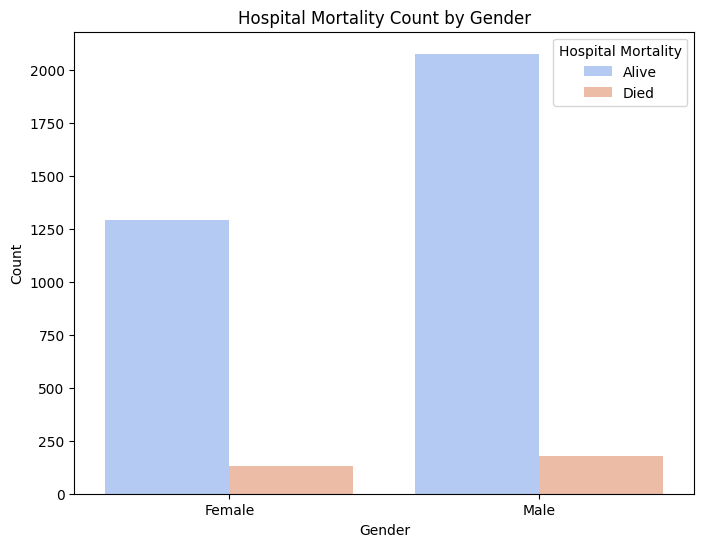

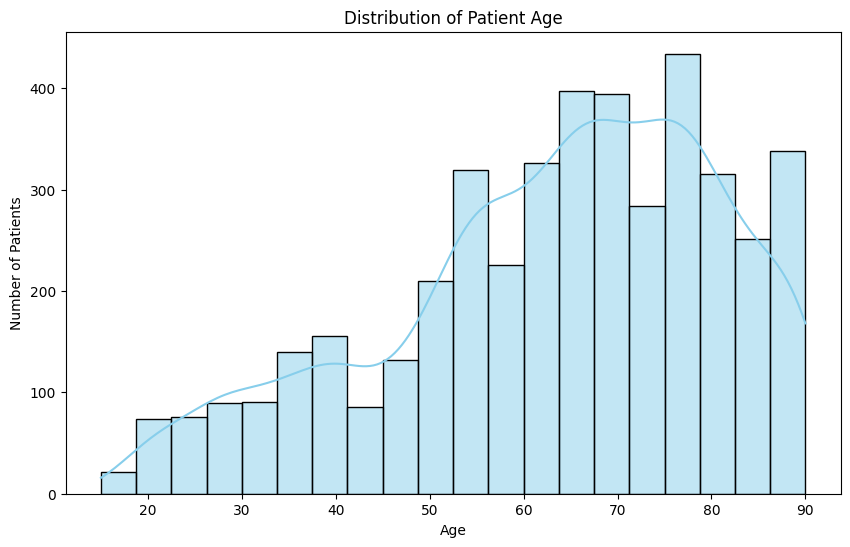

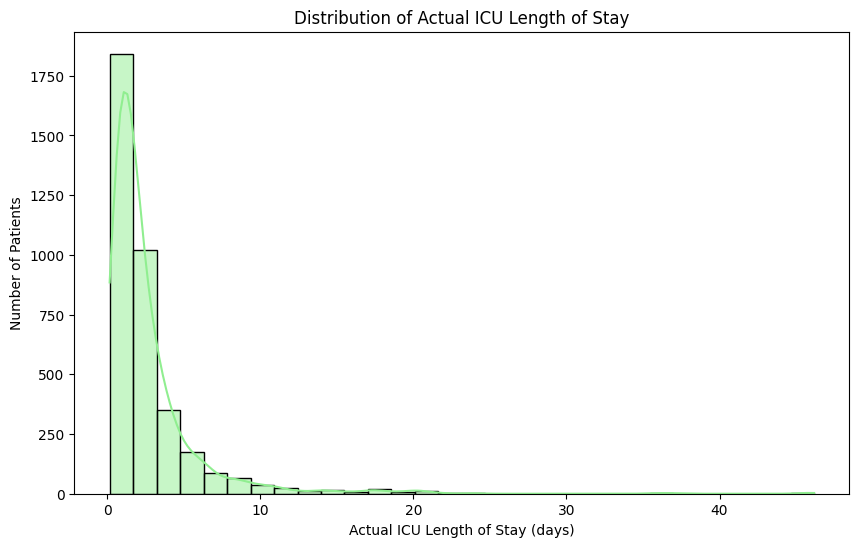

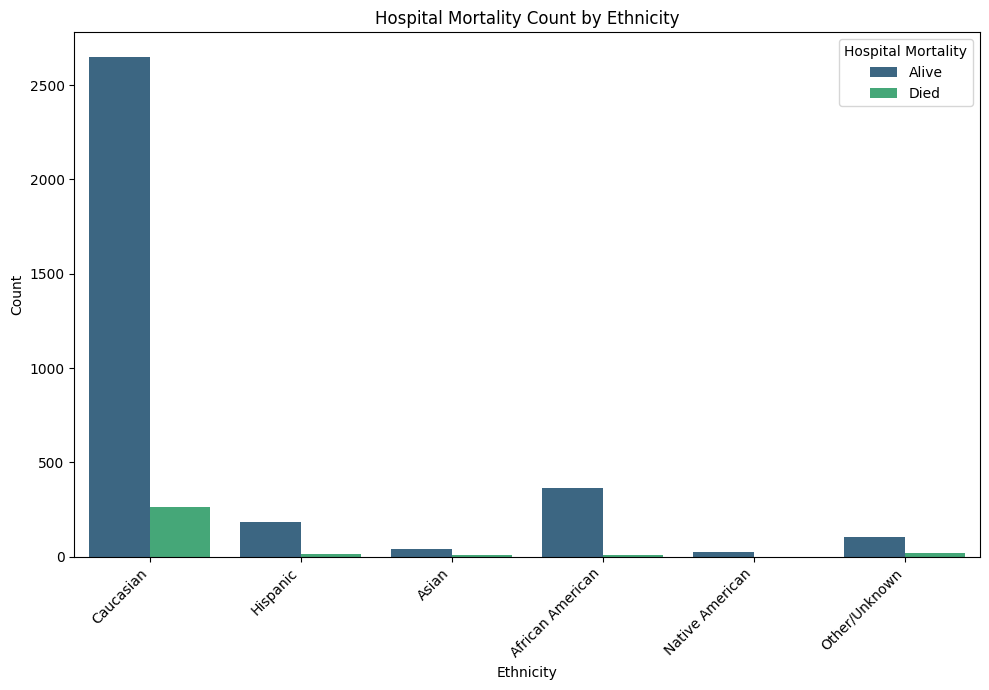

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hospital Mortality by Gender
plt.figure(figsize=(8, 6))
sns.countplot(data=merged_df, x='gender', hue='actualhospitalmortality', palette='coolwarm')
plt.title('Hospital Mortality Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Hospital Mortality', labels=['Alive', 'Died'])
plt.show()


# Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x='age', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

# ICU Length of Stay Distribution (actualiculos)
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x='actualiculos', bins=30, kde=True, color='lightgreen')
plt.title('Distribution of Actual ICU Length of Stay')
plt.xlabel('Actual ICU Length of Stay (days)')
plt.ylabel('Number of Patients')
plt.show()

# Hospital Mortality by Ethnicity
plt.figure(figsize=(10, 7))
sns.countplot(data=merged_df, x='ethnicity', hue='actualhospitalmortality', palette='viridis')
plt.title('Hospital Mortality Count by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Hospital Mortality', labels=['Alive', 'Died'])
plt.tight_layout()
plt.show()

### Correlation Analysis

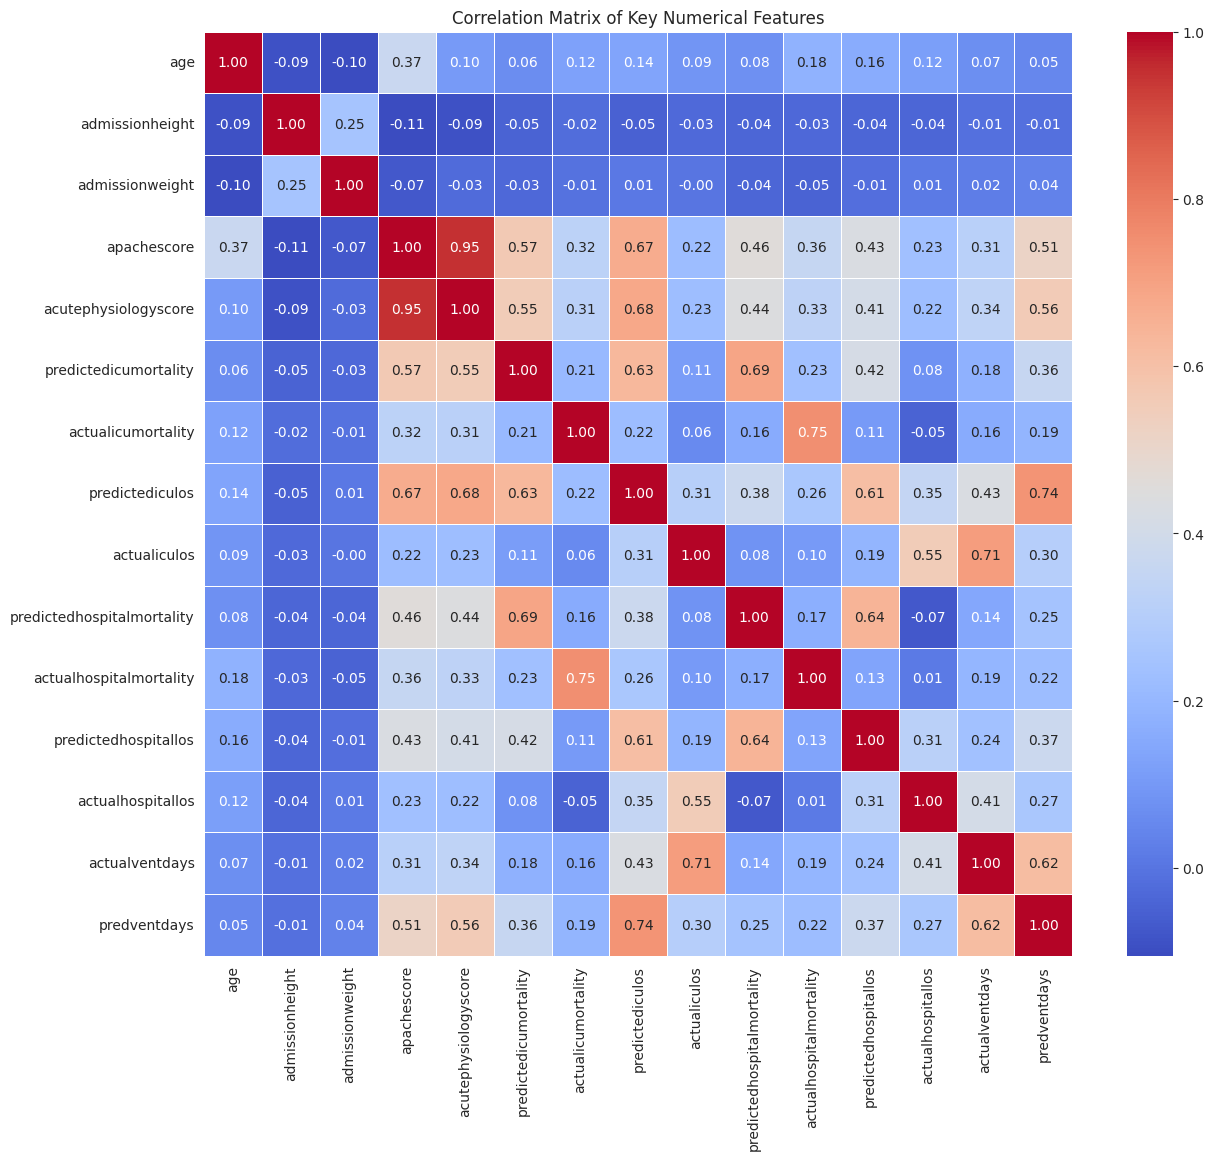

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


correlation_cols = [
    'age', 'admissionheight', 'admissionweight', 'apachescore',
    'acutephysiologyscore', 'predictedicumortality', 'actualicumortality',
    'predictediculos', 'actualiculos', 'predictedhospitalmortality',
    'actualhospitalmortality', 'predictedhospitallos', 'actualhospitallos',
    'actualventdays', 'predventdays'
]

correlation_cols = [col for col in correlation_cols if col in merged_df.columns]

# Ccorrelation matrix
corr_matrix = merged_df[correlation_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Key Numerical Features')
plt.show()

#### EDA on Time-Series Data: Vital Signs

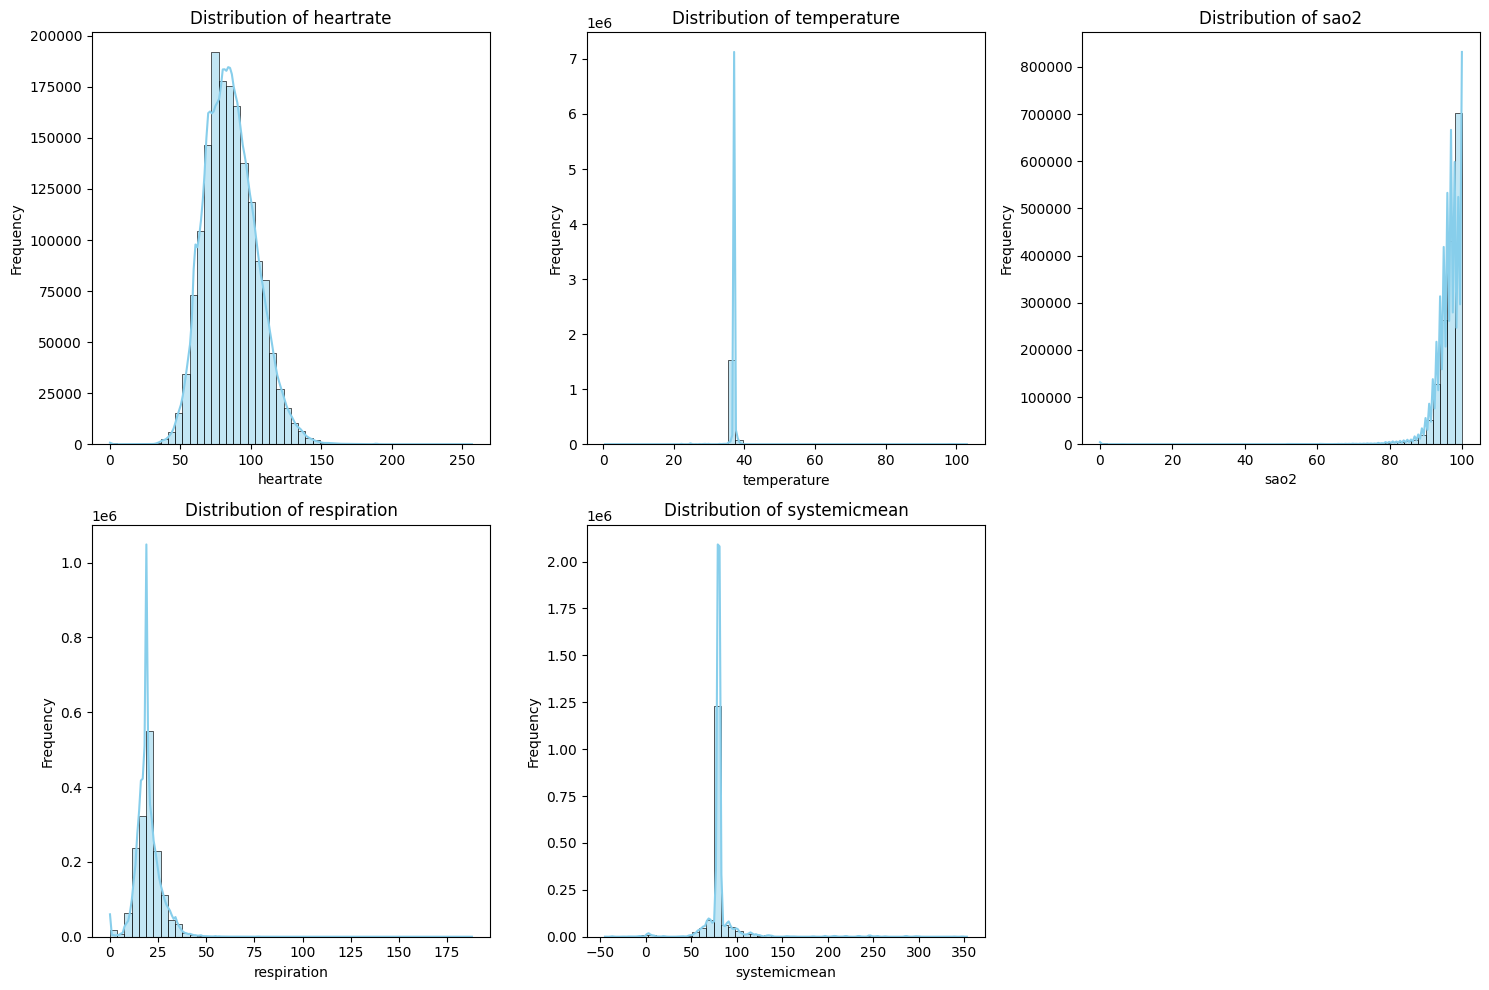

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of key vital signs (histograms)
vital_cols = ['heartrate', 'temperature', 'sao2', 'respiration', 'systemicmean']

plt.figure(figsize=(15, 10))
for i, col in enumerate(vital_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(vital_periodic_df[col], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Time-Series Plot for a Sample Patient

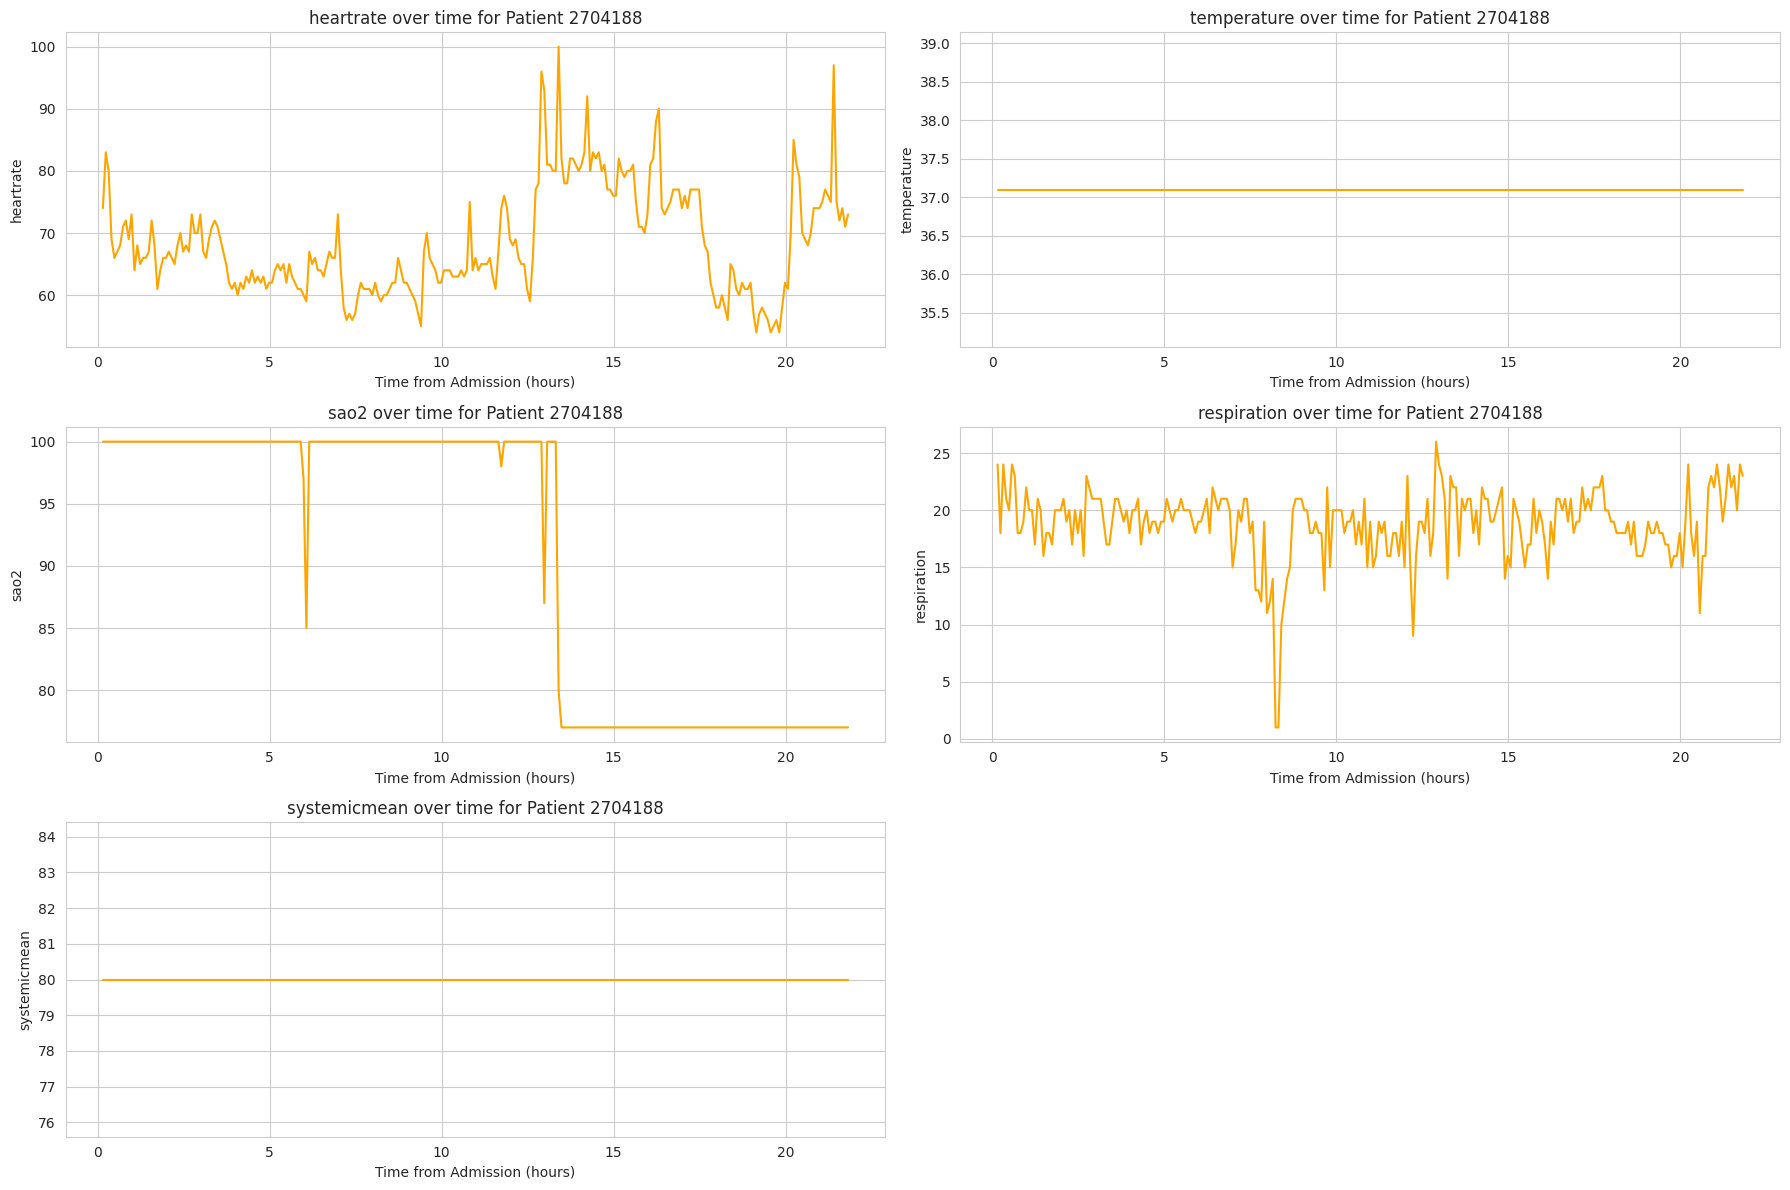

In [ ]:
# Selecting a random patient to visualize their vital signs over time
sample_patient_id = vital_periodic_df['patientunitstayid'].sample(1).iloc[0]
sample_patient_df = vital_periodic_df[vital_periodic_df['patientunitstayid'] == sample_patient_id]

plt.figure(figsize=(18, 12))
for i, col in enumerate(vital_cols):
    plt.subplot(3, 2, i + 1)
    sns.lineplot(x='observationoffset_hours', y=col, data=sample_patient_df, color='orange')
    plt.title(f'{col} over time for Patient {sample_patient_id}')
    plt.xlabel('Time from Admission (hours)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### APACHE Score Distribution by Hospital Mortality

/tmp/ipykernel_7572/551467291.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=merged_df, x='actualhospitalmortality', y='apachescore', palette='coolwarm')


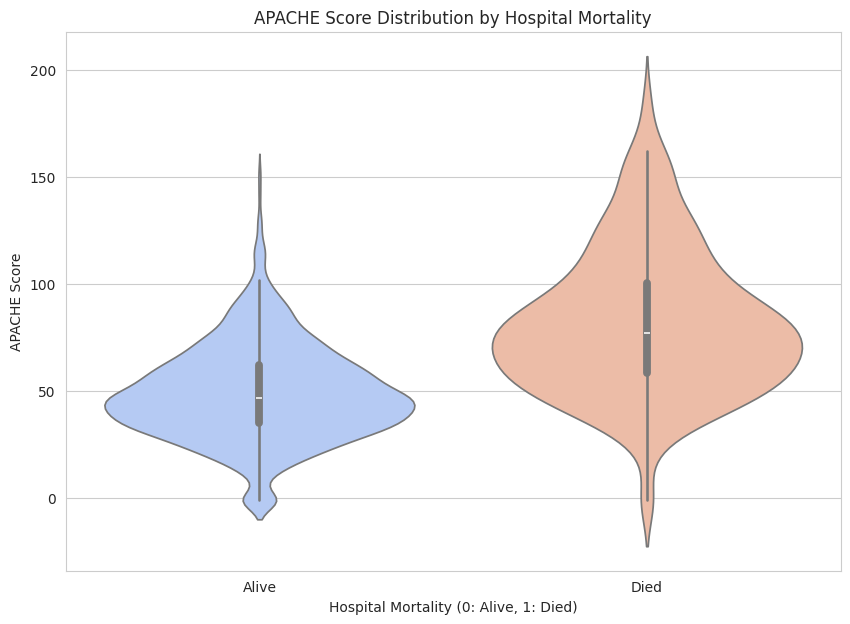

In [ ]:

plt.figure(figsize=(10, 7))
sns.violinplot(data=merged_df, x='actualhospitalmortality', y='apachescore', palette='coolwarm')
plt.title('APACHE Score Distribution by Hospital Mortality')
plt.xlabel('Hospital Mortality (0: Alive, 1: Died)')
plt.ylabel('APACHE Score')
plt.xticks(ticks=[0, 1], labels=['Alive', 'Died'])
plt.show()

#### Distribution of ICU Length of Stay by Hospital Mortality

/tmp/ipykernel_7572/1390093440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='actualhospitalmortality', y='actualiculos', palette='plasma')


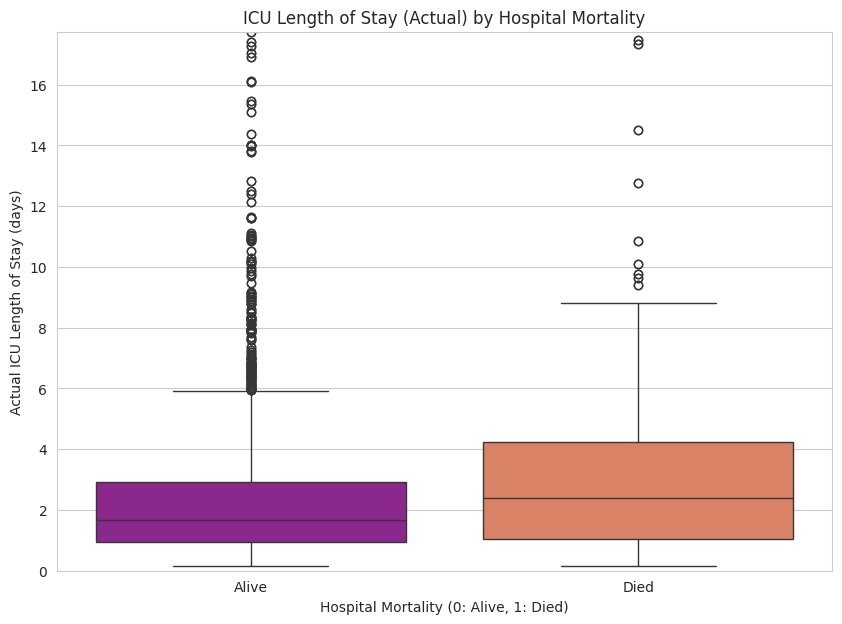

In [ ]:

plt.figure(figsize=(10, 7))
sns.boxplot(data=merged_df, x='actualhospitalmortality', y='actualiculos', palette='plasma')
plt.title('ICU Length of Stay (Actual) by Hospital Mortality')
plt.xlabel('Hospital Mortality (0: Alive, 1: Died)')
plt.ylabel('Actual ICU Length of Stay (days)')
plt.xticks(ticks=[0, 1], labels=['Alive', 'Died'])
plt.ylim(0, merged_df['actualiculos'].quantile(0.99))
plt.show()

## Feature Engineering

#### Aggregating Time-Series Vital Signs

In [ ]:
# extracting time-series features
def extract_time_series_features(df, vital_columns, window_hours=24):


    df_window = df[df['observationoffset_hours'] <= window_hours]

    # Group by patientunitstayid and calculating aggregates
    agg_funcs = ['mean', 'min', 'max', 'std']
    features = df_window.groupby('patientunitstayid')[vital_columns].agg(agg_funcs)


    features.columns = ['_'.join(col).strip() for col in features.columns.values]
    features = features.reset_index()

    return features


all_vital_cols = vital_periodic_df.columns.drop(['vitalperiodicid', 'patientunitstayid', 'observationoffset', 'observationoffset_hours']).tolist()

# Extracting features for the first 24 hours
vital_features_24h = extract_time_series_features(vital_periodic_df, all_vital_cols, window_hours=24)

print("Engineered vital sign features for the first 24 hours:")
display(vital_features_24h.head())
print(f"Shape of vital_features_24h: {vital_features_24h.shape}")

# Merging these features with the main merged_df
merged_df_with_vitals = pd.merge(merged_df, vital_features_24h, on='patientunitstayid', how='left')

print("\nMerged DataFrame with new vital sign features:")
display(merged_df_with_vitals.head())
print(f"Shape of merged_df_with_vitals: {merged_df_with_vitals.shape}")

# Checking for new NaNs introduced by the merge (
print("\nMissing values after merging vital features:")
display(merged_df_with_vitals.isnull().sum()[merged_df_with_vitals.isnull().sum() > 0].sort_values(ascending=False))

# Imputing any remaining NaNs in the new vital features

for col in vital_features_24h.columns.drop('patientunitstayid'):
    if merged_df_with_vitals[col].isnull().any():
        median_val = merged_df_with_vitals[col].median()
        merged_df_with_vitals[col].fillna(median_val, inplace=True)

print("\nMissing values in merged_df_with_vitals after final imputation for new features:")
display(merged_df_with_vitals.isnull().sum()[merged_df_with_vitals.isnull().sum() > 0])

print("\nUpdated 'merged_df_with_vitals' info after feature engineering:")
merged_df_with_vitals.info()

Engineered vital sign features for the first 24 hours:


,patientunitstayid,temperature_mean,temperature_min,temperature_max,temperature_std,sao2_mean,sao2_min,sao2_max,sao2_std,heartrate_mean,...,st2_max,st2_std,st3_mean,st3_min,st3_max,st3_std,icp_mean,icp_min,icp_max,icp_std
0,141764,37.1,37.1,37.1,0.0,97.000000,97.0,97.0,0.000000,106.652174,...,-0.7,0.361022,-0.997101,-1.7,-0.5,0.398147,11.0,11.0,11.0,0.0
1,141765,37.1,37.1,37.1,0.0,96.704861,95.0,98.0,0.618848,83.190972,...,-0.5,0.206458,-0.712847,-0.9,-0.4,0.063093,11.0,11.0,11.0,0.0
2,143870,37.1,37.1,37.1,0.0,96.284810,80.0,100.0,2.243438,45.449367,...,0.2,0.048208,0.124684,0.0,0.3,0.051335,11.0,11.0,11.0,0.0
3,144815,37.1,37.1,37.1,0.0,98.731818,96.0,100.0,0.825333,83.800000,...,0.2,0.120471,-0.053636,-0.9,0.0,0.096564,11.0,11.0,11.0,0.0
4,145427,37.1,37.1,37.1,0.0,96.815126,89.0,100.0,1.827896,65.457983,...,0.5,0.134240,0.087605,-0.2,0.4,0.130738,11.0,11.0,11.0,0.0


Shape of vital_features_24h: (2371, 65)

Merged DataFrame with new vital sign features:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,st2_max,st2_std,st3_mean,st3_min,st3_max,st3_std,icp_mean,icp_min,icp_max,icp_std
0,141764,129391,Female,87.0,Caucasian,59,91,"Sepsis, pulmonary",157.5,23:36:00,...,-0.7,0.361022,-0.997101,-1.7,-0.5,0.398147,11.0,11.0,11.0,0.0
1,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-0.5,0.206458,-0.712847,-0.9,-0.4,0.063093,11.0,11.0,11.0,0.0
2,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-0.5,0.206458,-0.712847,-0.9,-0.4,0.063093,11.0,11.0,11.0,0.0
3,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.2,0.048208,0.124684,0.0,0.3,0.051335,11.0,11.0,11.0,0.0
4,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.2,0.048208,0.124684,0.0,0.3,0.051335,11.0,11.0,11.0,0.0


Shape of merged_df_with_vitals: (4358, 524)

Missing values after merging vital features:


,0
apachepatientresultsid,682
physicianspeciality,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
...,...
st3_mean,181
st3_max,181
icp_mean,181
icp_min,181



Missing values in merged_df_with_vitals after final imputation for new features:


/tmp/ipykernel_7572/3483197068.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df_with_vitals[col].fillna(median_val, inplace=True)


,0
apachepatientresultsid,682
physicianspeciality,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
apacheversion,682
predictedicumortality,682
actualicumortality,682
predictediculos,682
actualiculos,682



Updated 'merged_df_with_vitals' info after feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 524 entries, patientunitstayid to icp_std
dtypes: float64(496), int64(9), object(19)
memory usage: 17.4+ MB


In [ ]:
# Merging these features with the main merged_df (which now includes lab and med features)
merged_df_with_vitals = pd.merge(merged_df, vital_features_24h, on='patientunitstayid', how='left')

print("\nMerged DataFrame with new vital sign features and updated merged_df:")
display(merged_df_with_vitals.head())
print(f"Shape of merged_df_with_vitals: {merged_df_with_vitals.shape}")

# Checking for new NaNs introduced by the merge (these should be imputed if necessary)
print("\nMissing values after merging vital features (updated):")
display(merged_df_with_vitals.isnull().sum()[merged_df_with_vitals.isnull().sum() > 0].sort_values(ascending=False))

# Imputing any remaining NaNs in the new vital features
for col in vital_features_24h.columns.drop('patientunitstayid'):
    if merged_df_with_vitals[col].isnull().any():
        median_val = merged_df_with_vitals[col].median()
        merged_df_with_vitals[col].fillna(median_val, inplace=True)

print("\nMissing values in merged_df_with_vitals after final imputation for new features (updated):")
display(merged_df_with_vitals.isnull().sum()[merged_df_with_vitals.isnull().sum() > 0])

print("\nUpdated 'merged_df_with_vitals' info after feature engineering (updated):")
merged_df_with_vitals.info()


Merged DataFrame with new vital sign features and updated merged_df:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,st2_max,st2_std,st3_mean,st3_min,st3_max,st3_std,icp_mean,icp_min,icp_max,icp_std
0,141764,129391,Female,87.0,Caucasian,59,91,"Sepsis, pulmonary",157.5,23:36:00,...,-0.7,0.361022,-0.997101,-1.7,-0.5,0.398147,11.0,11.0,11.0,0.0
1,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-0.5,0.206458,-0.712847,-0.9,-0.4,0.063093,11.0,11.0,11.0,0.0
2,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-0.5,0.206458,-0.712847,-0.9,-0.4,0.063093,11.0,11.0,11.0,0.0
3,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.2,0.048208,0.124684,0.0,0.3,0.051335,11.0,11.0,11.0,0.0
4,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.2,0.048208,0.124684,0.0,0.3,0.051335,11.0,11.0,11.0,0.0


Shape of merged_df_with_vitals: (4358, 524)

Missing values after merging vital features (updated):


,0
apachepatientresultsid,682
physicianspeciality,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
...,...
st3_mean,181
st3_max,181
icp_mean,181
icp_min,181



Missing values in merged_df_with_vitals after final imputation for new features (updated):


/tmp/ipykernel_7572/3272295861.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df_with_vitals[col].fillna(median_val, inplace=True)


,0
apachepatientresultsid,682
physicianspeciality,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
apacheversion,682
predictedicumortality,682
actualicumortality,682
predictediculos,682
actualiculos,682



Updated 'merged_df_with_vitals' info after feature engineering (updated):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 524 entries, patientunitstayid to icp_std
dtypes: float64(496), int64(9), object(19)
memory usage: 17.4+ MB


#### Merging Diagnosis and Treatment Features

In [ ]:
print("\n--- Merging diagnosis_features and treatment_features ---\n")

# Merge diagnosis_features into the main DataFrame
merged_df_with_all_features = pd.merge(merged_df_with_vitals, diagnosis_features, on='patientunitstayid', how='left')

# Merge treatment_features into the main DataFrame
merged_df_with_all_features = pd.merge(merged_df_with_all_features, treatment_features, on='patientunitstayid', how='left')

print("First 5 rows of the DataFrame with all features:")
display(merged_df_with_all_features.head())

print("\nColumn information (types, non-null counts) of the DataFrame with all features:")
merged_df_with_all_features.info()

print("\nMissing values after merging diagnosis and treatment features (before imputation):")
display(merged_df_with_all_features.isnull().sum()[merged_df_with_all_features.isnull().sum() > 0].sort_values(ascending=False))

# Impute NaNs introduced by the merges (for patients without diagnosis/treatment records)
# For count-based features, filling with 0 is appropriate.
for col in ['num_unique_diagnoses', 'num_major_diagnoses', 'num_unique_treatments', 'num_treatments_24h']:
    if col in merged_df_with_all_features.columns and merged_df_with_all_features[col].isnull().any():
        merged_df_with_all_features[col].fillna(0, inplace=True)

print("\nMissing values after imputation for diagnosis and treatment features:")
display(merged_df_with_all_features.isnull().sum()[merged_df_with_all_features.isnull().sum() > 0])

merged_df_with_vitals = merged_df_with_all_features

print("\nUpdated 'merged_df_with_vitals' info after merging all features:")
merged_df_with_vitals.info()


--- Merging diagnosis_features and treatment_features ---

First 5 rows of the DataFrame with all features:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,st3_max,st3_std,icp_mean,icp_min,icp_max,icp_std,num_unique_diagnoses,num_major_diagnoses,num_unique_treatments,num_treatments_24h
0,141764,129391,Female,87.0,Caucasian,59,91,"Sepsis, pulmonary",157.5,23:36:00,...,-0.5,0.398147,11.0,11.0,11.0,0.0,NaN,NaN,NaN,NaN
1,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-0.4,0.063093,11.0,11.0,11.0,0.0,NaN,NaN,NaN,NaN
2,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-0.4,0.063093,11.0,11.0,11.0,0.0,NaN,NaN,NaN,NaN
3,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.3,0.051335,11.0,11.0,11.0,0.0,3.0,0.0,NaN,NaN
4,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.3,0.051335,11.0,11.0,11.0,0.0,3.0,0.0,NaN,NaN



Column information (types, non-null counts) of the DataFrame with all features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 528 entries, patientunitstayid to num_treatments_24h
dtypes: float64(500), int64(9), object(19)
memory usage: 17.6+ MB

Missing values after merging diagnosis and treatment features (before imputation):


,0
num_unique_treatments,893
num_treatments_24h,893
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
apacheversion,682
predictedicumortality,682
actualicumortality,682
apachepatientresultsid,682
physicianspeciality,682



Missing values after imputation for diagnosis and treatment features:


/tmp/ipykernel_7572/1391384806.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df_with_all_features[col].fillna(0, inplace=True)


,0
apachepatientresultsid,682
physicianspeciality,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
apacheversion,682
predictedicumortality,682
actualicumortality,682
predictediculos,682
actualiculos,682



Updated 'merged_df_with_vitals' info after merging all features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 528 entries, patientunitstayid to num_treatments_24h
dtypes: float64(500), int64(9), object(19)
memory usage: 17.6+ MB


In [ ]:

merged_df_all_features = pd.merge(patient_df, apache_df, on='patientunitstayid', how='left')

# Merge lab features
merged_df_all_features = pd.merge(merged_df_all_features, lab_features, on='patientunitstayid', how='left')

#medication features
merged_df_all_features = pd.merge(merged_df_all_features, med_features, on='patientunitstayid', how='left')

# vital aperiodic features
merged_df_all_features = pd.merge(merged_df_all_features, vital_aperiodic_features, on='patientunitstayid', how='left')

# vital periodic features (24h)
merged_df_all_features = pd.merge(merged_df_all_features, vital_features_24h, on='patientunitstayid', how='left')

# diagnosis features
merged_df_all_features = pd.merge(merged_df_all_features, diagnosis_features, on='patientunitstayid', how='left')

# treatment features
merged_df_all_features = pd.merge(merged_df_all_features, treatment_features, on='patientunitstayid', how='left')

print("First 5 rows of the comprehensive merged DataFrame:")
display(merged_df_all_features.head())

print("\nColumn information (types, non-null counts) of the comprehensive merged DataFrame:")
merged_df_all_features.info()

print("\nMissing values in merged_df_all_features after initial merges (before final imputation):")
display(merged_df_all_features.isnull().sum()[merged_df_all_features.isnull().sum() > 0].sort_values(ascending=False))

for col in merged_df_all_features.select_dtypes(include=np.number).columns:
    if merged_df_all_features[col].isnull().any():
        merged_df_all_features[col].fillna(merged_df_all_features[col].median(), inplace=True)

for col in merged_df_all_features.select_dtypes(include='object').columns:
    if merged_df_all_features[col].isnull().any():
        merged_df_all_features[col].fillna('Unknown', inplace=True)

print("\nMissing values in merged_df_all_features after final imputation:")
display(merged_df_all_features.isnull().sum()[merged_df_all_features.isnull().sum() > 0])

print(f"Final shape of merged_df_all_features: {merged_df_all_features.shape}")

First 5 rows of the comprehensive merged DataFrame:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,st3_max,st3_std,icp_mean,icp_min,icp_max,icp_std,num_unique_diagnoses,num_major_diagnoses,num_unique_treatments,num_treatments_24h
0,141764,129391,Female,87.0,Caucasian,59,91,"Sepsis, pulmonary",157.5,23:36:00,...,-0.5,0.398147,11.0,11.0,11.0,0.0,NaN,NaN,NaN,NaN
1,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-0.4,0.063093,11.0,11.0,11.0,0.0,NaN,NaN,NaN,NaN
2,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-0.4,0.063093,11.0,11.0,11.0,0.0,NaN,NaN,NaN,NaN
3,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.3,0.051335,11.0,11.0,11.0,0.0,3.0,0.0,NaN,NaN
4,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.3,0.051335,11.0,11.0,11.0,0.0,3.0,0.0,NaN,NaN



Column information (types, non-null counts) of the comprehensive merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 568 entries, patientunitstayid to num_treatments_24h
dtypes: float64(540), int64(9), object(19)
memory usage: 18.9+ MB

Missing values in merged_df_all_features after initial merges (before final imputation):


,0
paop_std,4333
pvri_std,4333
pvr_std,4333
pvri_max,4331
pvri_min,4331
...,...
lab_LPM O2_min,96
lab_LDL_min,96
lab_LDH_min,96
lab_Hgb_min,96


/tmp/ipykernel_7572/147339828.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df_all_features[col].fillna(merged_df_all_features[col].median(), inplace=True)



Missing values in merged_df_all_features after final imputation:


/tmp/ipykernel_7572/147339828.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df_all_features[col].fillna('Unknown', inplace=True)


,0


Final shape of merged_df_all_features: (4358, 568)


### Cardinality Analysis of Categorical Features

In [ ]:
print("Cardinality of categorical columns:")
for col in merged_df_all_features.select_dtypes(include='object').columns.tolist():
    print(f"- {col}: {merged_df_all_features[col].nunique()} unique values")

Cardinality of categorical columns:
- gender: 2 unique values
- ethnicity: 6 unique values
- apacheadmissiondx: 236 unique values
- hospitaladmittime24: 1339 unique values
- hospitaladmitsource: 13 unique values
- hospitaldischargetime24: 715 unique values
- hospitaldischargelocation: 8 unique values
- hospitaldischargestatus: 2 unique values
- unittype: 8 unique values
- unitadmittime24: 1148 unique values
- unitadmitsource: 13 unique values
- unitstaytype: 4 unique values
- unitdischargetime24: 978 unique values
- unitdischargelocation: 15 unique values
- unitdischargestatus: 2 unique values
- uniquepid: 1841 unique values
- physicianspeciality: 35 unique values
- physicianinterventioncategory: 5 unique values
- apacheversion: 3 unique values


In [ ]:
print("Original number of columns:", merged_df_all_features.shape[1])

categorical_cols = merged_df_all_features.select_dtypes(include='object').columns.tolist()

print("\nCategorical columns identified:", categorical_cols)

columns_to_exclude = [
    'hospitaladmittime24', 'hospitaldischargetime24', 'unitadmittime24',
    'unitdischargetime24', 'uniquepid'
]

categorical_cols_to_encode = [col for col in categorical_cols if col not in columns_to_exclude]

# Apply one-hot encoding to the identified categorical columns (excluding high-cardinality ones)
merged_df_encoded = pd.get_dummies(merged_df_all_features, columns=categorical_cols_to_encode, drop_first=True)

merged_df_encoded = merged_df_encoded.drop(columns=columns_to_exclude, errors='ignore')

print("\nNumber of columns after one-hot encoding and exclusion:", merged_df_encoded.shape[1])

print("\nFirst 5 rows of the DataFrame after encoding:")
display(merged_df_encoded.head())

print("\nInfo of the DataFrame after encoding:")
merged_df_encoded.info()

Original number of columns: 568

Categorical columns identified: ['gender', 'ethnicity', 'apacheadmissiondx', 'hospitaladmittime24', 'hospitaladmitsource', 'hospitaldischargetime24', 'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitstaytype', 'unitdischargetime24', 'unitdischargelocation', 'unitdischargestatus', 'uniquepid', 'physicianspeciality', 'physicianinterventioncategory', 'apacheversion']

Number of columns after one-hot encoding and exclusion: 887

First 5 rows of the DataFrame after encoding:


,patientunitstayid,patienthealthsystemstayid,age,hospitalid,wardid,admissionheight,hospitaladmitoffset,hospitaldischargeyear,hospitaldischargeoffset,unitvisitnumber,...,physicianspeciality_surgery-trauma,physicianspeciality_surgery-vascular,physicianspeciality_unknown,physicianspeciality_urology,physicianinterventioncategory_II,physicianinterventioncategory_III,physicianinterventioncategory_IV,physicianinterventioncategory_Unknown,apacheversion_IVa,apacheversion_Unknown
0,141764,129391,87.0,59,91,157.5,-2258,2015,366,2,...,False,False,False,False,False,False,False,True,False,True
1,141765,129391,87.0,59,91,157.5,-8,2015,2616,1,...,False,False,False,False,False,False,False,True,False,False
2,141765,129391,87.0,59,91,157.5,-8,2015,2616,1,...,False,False,False,False,False,False,False,True,True,False
3,143870,131022,76.0,68,103,167.0,-1,2014,1218,1,...,False,False,False,False,False,False,False,True,True,False
4,143870,131022,76.0,68,103,167.0,-1,2014,1218,1,...,False,False,False,False,False,False,False,True,False,False



Info of the DataFrame after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 887 entries, patientunitstayid to apacheversion_Unknown
dtypes: bool(338), float64(540), int64(9)
memory usage: 19.7 MB


##  PCA

Shape of X before scaling: (4358, 884)


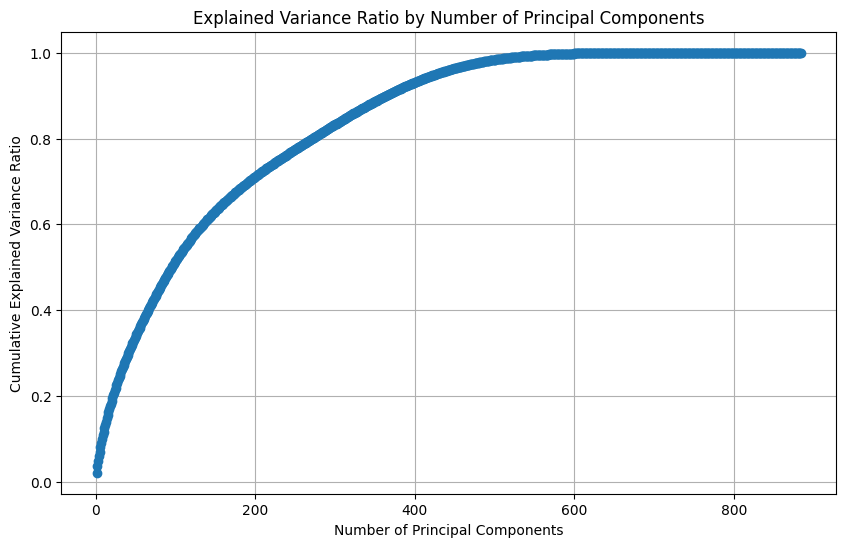


Number of components to explain 95% variance: 427

First 5 rows of the DataFrame after PCA:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_420,PC_421,PC_422,PC_423,PC_424,PC_425,PC_426,PC_427,patientunitstayid,actualhospitalmortality
0,3.574262,1.022043,-1.438907,-2.089460,-0.646062,0.807684,-0.248179,1.052895,-0.809630,-0.694382,...,-0.026342,-0.662675,0.627524,-0.402057,-0.251411,0.458225,0.332493,0.286319,141764,0.0
1,2.655522,-0.911180,-1.811789,-0.466277,-0.363892,0.096489,0.300040,0.568568,1.004532,-0.808812,...,0.754118,-0.079005,0.302151,0.521972,-0.166583,0.534601,0.035867,-0.481545,141765,0.0
2,2.589943,-0.925934,-1.780522,-0.387970,-0.347574,0.106891,0.304101,0.548631,0.980103,-0.725292,...,0.716721,-0.168705,0.278554,0.604357,-0.140526,0.436966,0.010935,-0.500262,141765,0.0
3,0.635183,0.214835,3.804789,-3.006749,-0.528796,-1.112437,-1.869163,1.076098,-0.704142,-2.328290,...,-0.348194,-0.052008,-1.153239,-0.170099,0.502749,0.015732,0.637944,-0.229015,143870,0.0
4,0.656365,0.234856,3.785099,-3.054753,-0.545243,-1.116775,-1.883825,1.103880,-0.699304,-2.390777,...,-0.309756,0.041216,-1.135714,-0.254342,0.487666,0.102843,0.670419,-0.213494,143870,0.0


Shape of merged_df_pca: (4358, 429)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 'actualhospitalmortality' is the target variable
y = merged_df_encoded['actualhospitalmortality']
X = merged_df_encoded.drop(columns=['actualhospitalmortality', 'actualicumortality', 'patientunitstayid'])

print(f"Shape of X before scaling: {X.shape}")

# Standardizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=None)
X_pca = pca.fit_transform(X_scaled)

#  variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio.cumsum(), marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()


n_components_95 = (explained_variance_ratio.cumsum() < 0.95).sum() + 1
print(f"\nNumber of components to explain 95% variance: {n_components_95}")

pca_final = PCA(n_components=n_components_95)
X_pca_final = pca_final.fit_transform(X_scaled)

# df principal components
pca_columns = [f'PC_{i+1}' for i in range(n_components_95)]
merged_df_pca = pd.DataFrame(data=X_pca_final, columns=pca_columns)


merged_df_pca['patientunitstayid'] = merged_df_encoded['patientunitstayid']
merged_df_pca['actualhospitalmortality'] = y

print("\nFirst 5 rows of the DataFrame after PCA:")
display(merged_df_pca.head())
print(f"Shape of merged_df_pca: {merged_df_pca.shape}")

## Predictive Modeling

###Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_final = merged_df_pca.drop(columns=['actualhospitalmortality', 'patientunitstayid'])
y_final = merged_df_pca['actualhospitalmortality']


X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of hospital mortality in original dataset:")
display(y_final.value_counts(normalize=True))
print("\nDistribution of hospital mortality in training set:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of hospital mortality in test set:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (3486, 427)
Shape of X_test: (872, 427)
Shape of y_train: (3486,)
Shape of y_test: (872,)

Distribution of hospital mortality in original dataset:


,proportion
actualhospitalmortality,
0.0,0.928866
1.0,0.071134



Distribution of hospital mortality in training set:


,proportion
actualhospitalmortality,
0.0,0.928858
1.0,0.071142



Distribution of hospital mortality in test set:


,proportion
actualhospitalmortality,
0.0,0.928899
1.0,0.071101


###Baseline Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n--- Training Logistic Regression Baseline Model ---")


logistic_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nLogistic Regression Baseline Model training and evaluation complete.")


--- Training Logistic Regression Baseline Model ---

Accuracy: 0.9920
Precision: 0.8986
Recall: 1.0000
F1-Score: 0.9466
ROC-AUC Score: 1.0000

Logistic Regression Baseline Model training and evaluation complete.


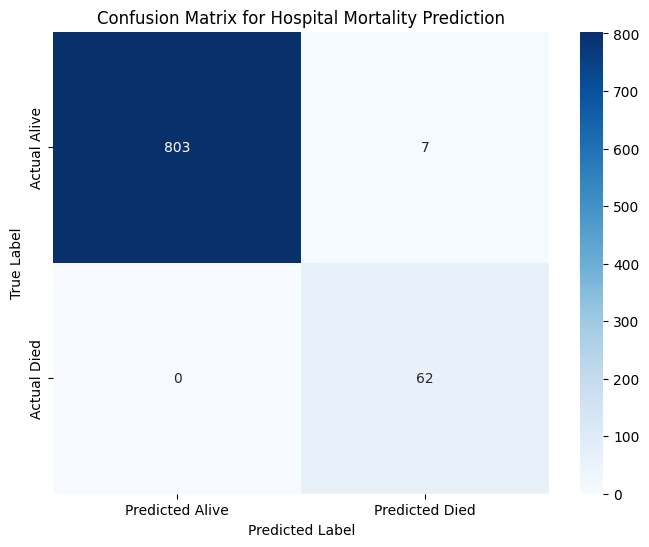


True Negatives (TN): 803
False Positives (FP): 7
False Negatives (FN): 0
True Positives (TP): 62

False Positive Rate (FPR): 0.0086


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#  confusion matrix
cm = confusion_matrix(y_test, y_pred)

#
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Alive', 'Predicted Died'], yticklabels=['Actual Alive', 'Actual Died'])
plt.title('Confusion Matrix for Hospital Mortality Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")


if (fp + tn) > 0:
    fpr = fp / (fp + tn)
    print(f"\nFalse Positive Rate (FPR): {fpr:.4f}")
else:
    print("\nCannot calculate FPR: Denominator (FP + TN) is zero.")

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- Training Random Forest Classifier ---")


rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")
print(f"Random Forest ROC-AUC Score: {roc_auc_rf:.4f}")

print("\nRandom Forest Classifier training and evaluation complete.")


--- Training Random Forest Classifier ---

Random Forest Accuracy: 0.9759
Random Forest Precision: 1.0000
Random Forest Recall: 0.6613
Random Forest F1-Score: 0.7961
Random Forest ROC-AUC Score: 0.9808

Random Forest Classifier training and evaluation complete.


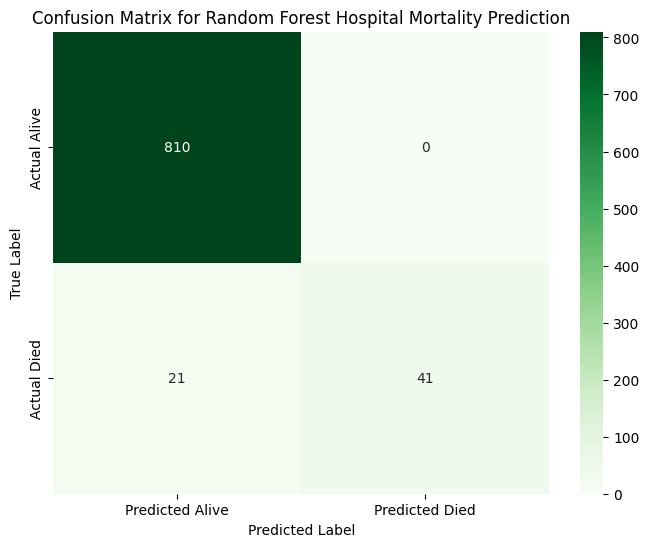


Random Forest True Negatives (TN): 810
Random Forest False Positives (FP): 0
Random Forest False Negatives (FN): 21
Random Forest True Positives (TP): 41

Random Forest False Positive Rate (FPR): 0.0000


In [ ]:
#confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)


plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Predicted Alive', 'Predicted Died'], yticklabels=['Actual Alive', 'Actual Died'])
plt.title('Confusion Matrix for Random Forest Hospital Mortality Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(f"\nRandom Forest True Negatives (TN): {tn_rf}")
print(f"Random Forest False Positives (FP): {fp_rf}")
print(f"Random Forest False Negatives (FN): {fn_rf}")
print(f"Random Forest True Positives (TP): {tp_rf}")


if (fp_rf + tn_rf) > 0:
    fpr_rf = fp_rf / (fp_rf + tn_rf)
    print(f"\nRandom Forest False Positive Rate (FPR): {fpr_rf:.4f}")
else:
    print("\nCannot calculate FPR for Random Forest: Denominator (FP + TN) is zero.")

### LightGBM

In [ ]:
import lightgbm as lgb

print("\n--- Training LightGBM Classifier ---")

lgbm_model = lgb.LGBMClassifier(objective='binary', is_unbalance=True, random_state=42)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
precision_lgbm = precision_score(y_test, y_pred_lgbm)
recall_lgbm = recall_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
roc_auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)

print(f"\nLightGBM Accuracy: {accuracy_lgbm:.4f}")
print(f"LightGBM Precision: {precision_lgbm:.4f}")
print(f"LightGBM Recall: {recall_lgbm:.4f}")
print(f"LightGBM F1-Score: {f1_lgbm:.4f}")
print(f"LightGBM ROC-AUC Score: {roc_auc_lgbm:.4f}")

print("\nLightGBM Classifier training and evaluation complete.")


--- Training LightGBM Classifier ---
[LightGBM] [Info] Number of positive: 248, number of negative: 3238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 108885
[LightGBM] [Info] Number of data points in the train set: 3486, number of used features: 427
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.071142 -> initscore=-2.569282
[LightGBM] [Info] Start training from score -2.569282

LightGBM Accuracy: 0.9920
LightGBM Precision: 0.9825
LightGBM Recall: 0.9032
LightGBM F1-Score: 0.9412
LightGBM ROC-AUC Score: 0.9930

LightGBM Classifier training and evaluation complete.


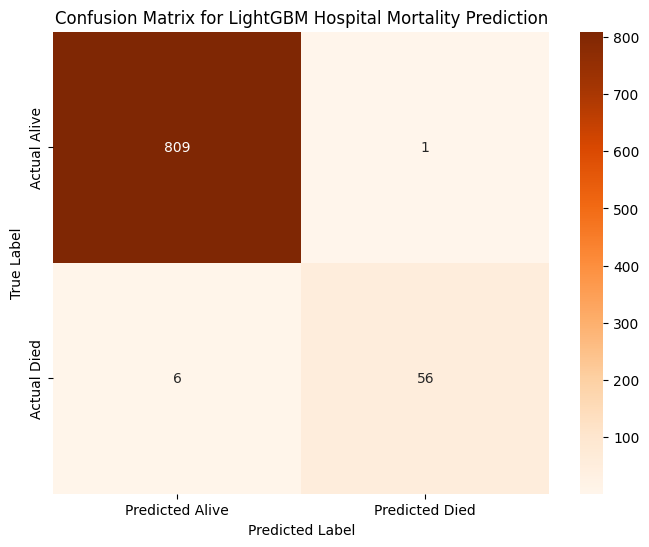


LightGBM True Negatives (TN): 809
LightGBM False Positives (FP): 1
LightGBM False Negatives (FN): 6
LightGBM True Positives (TP): 56

LightGBM False Positive Rate (FPR): 0.0012


In [ ]:
# confusion matrix for LightGBM
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Predicted Alive', 'Predicted Died'], yticklabels=['Actual Alive', 'Actual Died'])
plt.title('Confusion Matrix for LightGBM Hospital Mortality Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


tn_lgbm, fp_lgbm, fn_lgbm, tp_lgbm = cm_lgbm.ravel()

print(f"\nLightGBM True Negatives (TN): {tn_lgbm}")
print(f"LightGBM False Positives (FP): {fp_lgbm}")
print(f"LightGBM False Negatives (FN): {fn_lgbm}")
print(f"LightGBM True Positives (TP): {tp_lgbm}")

if (fp_lgbm + tn_lgbm) > 0:
    fpr_lgbm = fp_lgbm / (fp_lgbm + tn_lgbm)
    print(f"\nLightGBM False Positive Rate (FPR): {fpr_lgbm:.4f}")
else:
    print("\nCannot calculate FPR for LightGBM: Denominator (FP + TN) is zero.")

### XGBoost

In [ ]:
import xgboost as xgb

print("\n--- Training XGBoost Classifier ---")

# class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initializing
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

# Training
xgb_model.fit(X_train, y_train)

# predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]


accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"\nXGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Precision: {precision_xgb:.4f}")
print(f"XGBoost Recall: {recall_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")
print(f"XGBoost ROC-AUC Score: {roc_auc_xgb:.4f}")

print("\nXGBoost Classifier training and evaluation complete.")


--- Training XGBoost Classifier ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:09:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.9885
XGBoost Precision: 0.9333
XGBoost Recall: 0.9032
XGBoost F1-Score: 0.9180
XGBoost ROC-AUC Score: 0.9889

XGBoost Classifier training and evaluation complete.


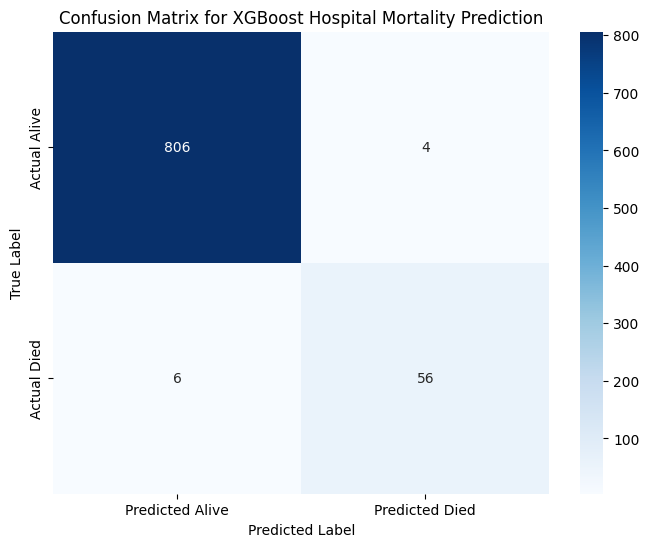


XGBoost True Negatives (TN): 806
XGBoost False Positives (FP): 4
XGBoost False Negatives (FN): 6
XGBoost True Positives (TP): 56

XGBoost False Positive Rate (FPR): 0.0049


In [ ]:
# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Alive', 'Predicted Died'], yticklabels=['Actual Alive', 'Actual Died'])
plt.title('Confusion Matrix for XGBoost Hospital Mortality Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

print(f"\nXGBoost True Negatives (TN): {tn_xgb}")
print(f"XGBoost False Positives (FP): {fp_xgb}")
print(f"XGBoost False Negatives (FN): {fn_xgb}")
print(f"XGBoost True Positives (TP): {tp_xgb}")

if (fp_xgb + tn_xgb) > 0:
    fpr_xgb = fp_xgb / (fp_xgb + tn_xgb)
    print(f"\nXGBoost False Positive Rate (FPR): {fpr_xgb:.4f}")
else:
    print("\nCannot calculate FPR for XGBoost: Denominator (FP + TN) is zero.")

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("\n--- Training K-Nearest Neighbors Classifier ---")


knn_model = KNeighborsClassifier(n_neighbors=5)

# Training
knn_model.fit(X_train, y_train)

# predictions
y_pred_knn = knn_model.predict(X_test)
y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1]

# Evaluating
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

print(f"\nKNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN Precision: {precision_knn:.4f}")
print(f"KNN Recall: {recall_knn:.4f}")
print(f"KNN F1-Score: {f1_knn:.4f}")
print(f"KNN ROC-AUC Score: {roc_auc_knn:.4f}")

print("\nK-Nearest Neighbors Classifier training and evaluation complete.")


--- Training K-Nearest Neighbors Classifier ---

KNN Accuracy: 0.9381
KNN Precision: 0.6818
KNN Recall: 0.2419
KNN F1-Score: 0.3571
KNN ROC-AUC Score: 0.8678

K-Nearest Neighbors Classifier training and evaluation complete.


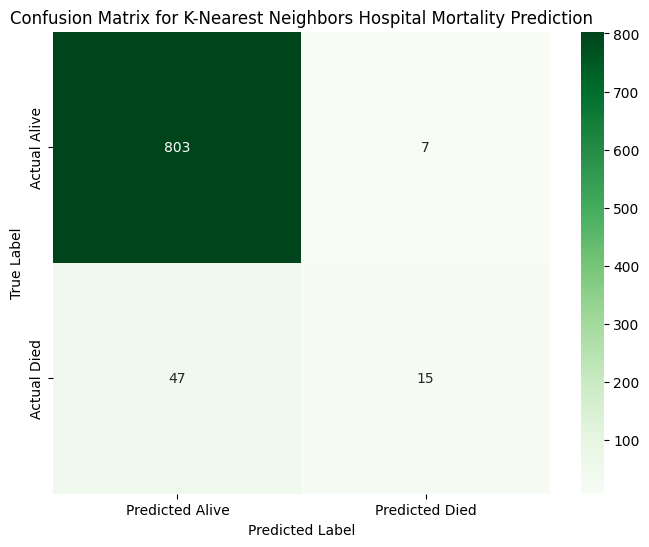


KNN True Negatives (TN): 803
KNN False Positives (FP): 7
KNN False Negatives (FN): 47
KNN True Positives (TP): 15

KNN False Positive Rate (FPR): 0.0086


In [ ]:
# Confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', xticklabels=['Predicted Alive', 'Predicted Died'], yticklabels=['Actual Alive', 'Actual Died'])
plt.title('Confusion Matrix for K-Nearest Neighbors Hospital Mortality Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

tn_knn, fp_knn, fn_knn, tp_knn = cm_knn.ravel()

print(f"\nKNN True Negatives (TN): {tn_knn}")
print(f"KNN False Positives (FP): {fp_knn}")
print(f"KNN False Negatives (FN): {fn_knn}")
print(f"KNN True Positives (TP): {tp_knn}")

if (fp_knn + tn_knn) > 0:
    fpr_knn = fp_knn / (fp_knn + tn_knn)
    print(f"\nKNN False Positive Rate (FPR): {fpr_knn:.4f}")
else:
    print("\nCannot calculate FPR for KNN: Denominator (FP + TN) is zero.")

## Hyperparameter Tuning for LightGBM

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

print("\n--- Starting LightGBM Hyperparameter Tuning (Randomized Search) ---")

# Defining the parameter grid to search
param_grid = {
    'num_leaves': [20, 31, 40, 50],
    'max_depth': [5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'n_estimators': [50, 100],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initializing LightGBM Classifier with class imbalance handling
lgbm = lgb.LGBMClassifier(objective='binary', is_unbalance=True, random_state=42)

# Initializing RandomizedSearchCV
grid_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=20,
    cv=2,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# Performing the random search
grid_search.fit(X_train, y_train)

print("\n--- LightGBM Hyperparameter Tuning (Randomized Search) Complete ---")


print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best ROC-AUC score: {grid_search.best_score_:.4f}")

# Getting the best model
best_lgbm_model = grid_search.best_estimator_

#predictions with the best model
y_pred_tuned_lgbm = best_lgbm_model.predict(X_test)
y_pred_proba_tuned_lgbm = best_lgbm_model.predict_proba(X_test)[:, 1]

# Evaluating the tuned model
accuracy_tuned_lgbm = accuracy_score(y_test, y_pred_tuned_lgbm)
precision_tuned_lgbm = precision_score(y_test, y_pred_tuned_lgbm)
recall_tuned_lgbm = recall_score(y_test, y_pred_tuned_lgbm)
f1_tuned_lgbm = f1_score(y_test, y_pred_tuned_lgbm)
roc_auc_tuned_lgbm = roc_auc_score(y_test, y_pred_proba_tuned_lgbm)

print(f"\nTuned LightGBM Accuracy: {accuracy_tuned_lgbm:.4f}")
print(f"Tuned LightGBM Precision: {precision_tuned_lgbm:.4f}")
print(f"Tuned LightGBM Recall: {recall_tuned_lgbm:.4f}")
print(f"Tuned LightGBM F1-Score: {f1_tuned_lgbm:.4f}")
print(f"Tuned LightGBM ROC-AUC Score: {roc_auc_tuned_lgbm:.4f}")

print("\nTuned LightGBM model evaluation complete.")


--- Starting LightGBM Hyperparameter Tuning (Randomized Search) ---
Fitting 2 folds for each of 20 candidates, totalling 40 fits
[LightGBM] [Info] Number of positive: 248, number of negative: 3238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 108885
[LightGBM] [Info] Number of data points in the train set: 3486, number of used features: 427
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.071142 -> initscore=-2.569282
[LightGBM] [Info] Start training from score -2.569282
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

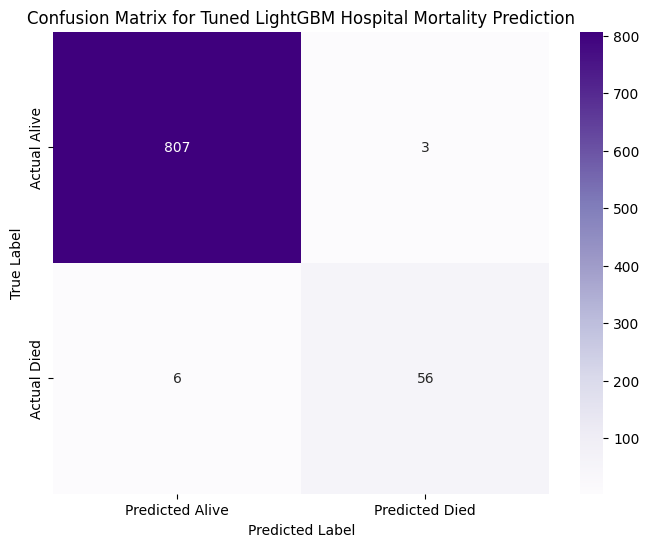


Tuned LightGBM True Negatives (TN): 807
Tuned LightGBM False Positives (FP): 3
Tuned LightGBM False Negatives (FN): 6
Tuned LightGBM True Positives (TP): 56

Tuned LightGBM False Positive Rate (FPR): 0.0037


In [ ]:
# Generating the confusion matrix for the Tuned LightGBM
cm_tuned_lgbm = confusion_matrix(y_test, y_pred_tuned_lgbm)


plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned_lgbm, annot=True, fmt='d', cmap='Purples', xticklabels=['Predicted Alive', 'Predicted Died'], yticklabels=['Actual Alive', 'Actual Died'])
plt.title('Confusion Matrix for Tuned LightGBM Hospital Mortality Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

tn_tuned_lgbm, fp_tuned_lgbm, fn_tuned_lgbm, tp_tuned_lgbm = cm_tuned_lgbm.ravel()

print(f"\nTuned LightGBM True Negatives (TN): {tn_tuned_lgbm}")
print(f"Tuned LightGBM False Positives (FP): {fp_tuned_lgbm}")
print(f"Tuned LightGBM False Negatives (FN): {fn_tuned_lgbm}")
print(f"Tuned LightGBM True Positives (TP): {tp_tuned_lgbm}")


if (fp_tuned_lgbm + tn_tuned_lgbm) > 0:
    fpr_tuned_lgbm = fp_tuned_lgbm / (fp_tuned_lgbm + tn_tuned_lgbm)
    print(f"\nTuned LightGBM False Positive Rate (FPR): {fpr_tuned_lgbm:.4f}")
else:
    print("\nCannot calculate FPR for Tuned LightGBM: Denominator (FP + TN) is zero.")

## Model Performance Comparison

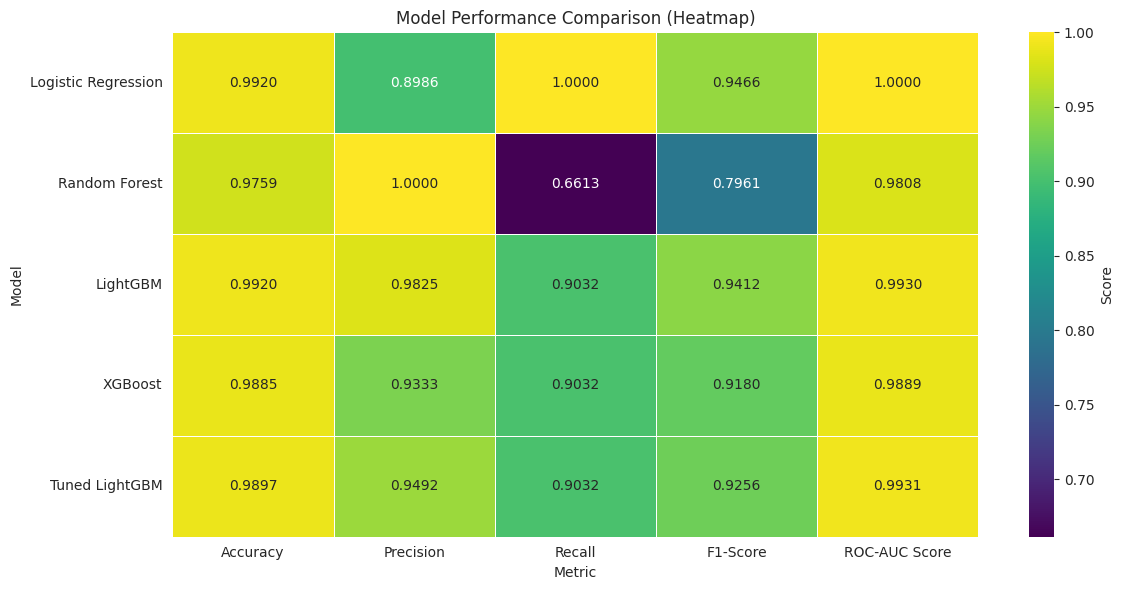

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_performance = {
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM', 'XGBoost', 'Tuned LightGBM'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_lgbm, accuracy_xgb, accuracy_tuned_lgbm],
    'Precision': [precision, precision_rf, precision_lgbm, precision_xgb, precision_tuned_lgbm],
    'Recall': [recall, recall_rf, recall_lgbm, recall_xgb, recall_tuned_lgbm],
    'F1-Score': [f1, f1_rf, f1_lgbm, f1_xgb, f1_tuned_lgbm],
    'ROC-AUC Score': [roc_auc, roc_auc_rf, roc_auc_lgbm, roc_auc_xgb, roc_auc_tuned_lgbm]
}

df = pd.DataFrame(model_performance)

df_heatmap = df.set_index('Model')

plt.figure(figsize=(12, 6))
sns.heatmap(
    df_heatmap,
    annot=True,
    cmap='viridis',
    fmt='.4f',
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
)
plt.title('Model Performance Comparison (Heatmap)')
plt.xlabel('Metric')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


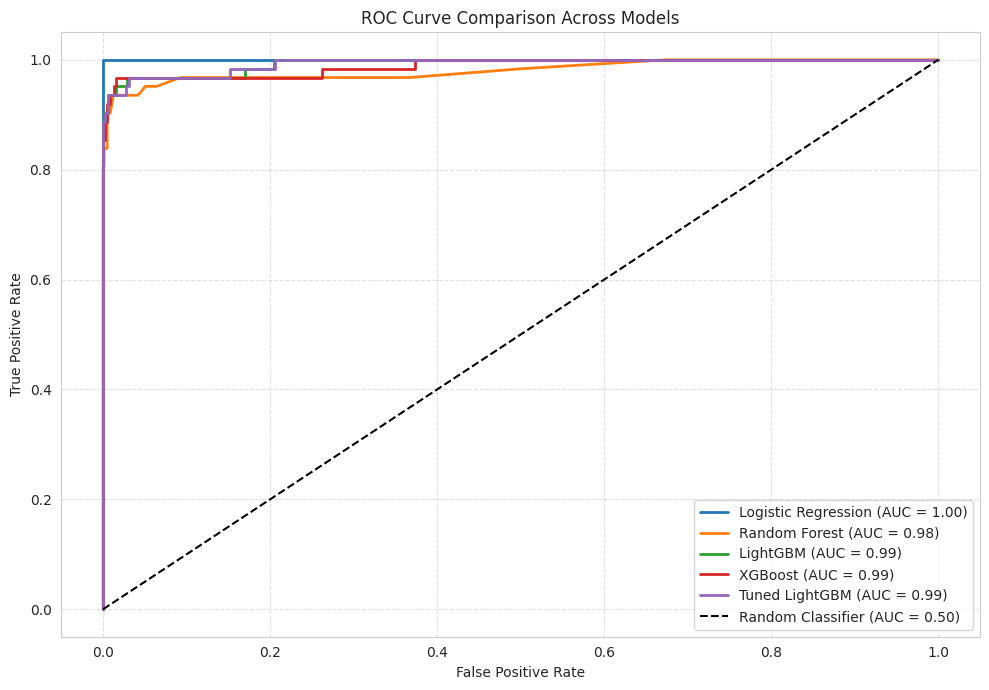

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

models = {
    "Logistic Regression": y_pred_proba,
    "Random Forest": y_pred_proba_rf,
    "LightGBM": y_pred_proba_lgbm,
    "XGBoost": y_pred_proba_xgb,
    "Tuned LightGBM": y_pred_proba_tuned_lgbm
}

for model_name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.50)")

plt.title("ROC Curve Comparison Across Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##Most Predictive Features

In [ ]:
vital_sign_cols = [
    'heartrate', 'temperature', 'sao2', 'respiration', 'cvp', 'etco2',
    'systemicsystolic', 'systemicdiastolic', 'systemicmean', 'pasystolic',
    'padiastolic', 'pamean', 'st1', 'st2', 'st3', 'icp'
]
# Group by patientunitstayid and calculate aggregates for vital signs
agg_funcs = ['mean', 'median', 'std', 'min', 'max']
trajectory_features_df = vital_periodic_df.groupby('patientunitstayid')[vital_sign_cols].agg(agg_funcs)

trajectory_features_df.columns = ['_'.join(col).strip() for col in trajectory_features_df.columns.values]

trajectory_features_df = trajectory_features_df.reset_index()

print("Shape of trajectory_features_df:", trajectory_features_df.shape)
print("First 5 rows of trajectory_features_df:")
display(trajectory_features_df.head())

Shape of trajectory_features_df: (2375, 81)
First 5 rows of trajectory_features_df:


,patientunitstayid,heartrate_mean,heartrate_median,heartrate_std,heartrate_min,heartrate_max,temperature_mean,temperature_median,temperature_std,temperature_min,...,st3_mean,st3_median,st3_std,st3_min,st3_max,icp_mean,icp_median,icp_std,icp_min,icp_max
0,141764,106.652174,104.0,11.339450,90.0,138.0,37.1,37.1,0.0,37.1,...,-0.997101,-0.8,0.398147,-1.7,-0.5,11.0,11.0,0.0,11.0,11.0
1,141765,87.017817,86.0,9.587689,72.0,138.0,37.1,37.1,0.0,37.1,...,-0.744098,-0.7,0.065582,-0.9,-0.4,11.0,11.0,0.0,11.0,11.0
2,143870,45.449367,46.0,2.594820,40.0,55.0,37.1,37.1,0.0,37.1,...,0.124684,0.1,0.051335,0.0,0.3,11.0,11.0,0.0,11.0,11.0
3,144815,83.800000,82.0,10.483560,68.0,118.0,37.1,37.1,0.0,37.1,...,-0.053636,0.0,0.096564,-0.9,0.0,11.0,11.0,0.0,11.0,11.0
4,145427,65.457983,64.0,7.862500,49.0,85.0,37.1,37.1,0.0,37.1,...,0.087605,0.0,0.130738,-0.2,0.4,11.0,11.0,0.0,11.0,11.0


In [ ]:
# Get the original feature names used in PCA
original_feature_names = X.columns

top_n_components = feature_importances.head(3).index.tolist()

print(f"Analyzing the top {len(top_n_components)} most important PCA components:")

for pc_name in top_n_components:

    pc_index = int(pc_name.split('_')[1]) - 1

    pc_loadings = pca_final.components_[pc_index]

    loadings_series = pd.Series(pc_loadings, index=original_feature_names)

    top_contributing_features = loadings_series.abs().sort_values(ascending=False).head(10)

    print(f"\n--- Component: {pc_name} ---")
    print("Top 10 contributing original features (by absolute loading):")
    display(loadings_series[top_contributing_features.index])
    positive_loadings = loadings_series[top_contributing_features.index[loadings_series[top_contributing_features.index] > 0]]
    negative_loadings = loadings_series[top_contributing_features.index[loadings_series[top_contributing_features.index] < 0]]

    print("Interpretation Hint (based on dominant positive/negative loadings):")
    if not positive_loadings.empty:
        print(f"  Tends to increase with: {', '.join(positive_loadings.index.tolist())}")
    if not negative_loadings.empty:
        print(f"  Tends to decrease with: {', '.join(negative_loadings.index.tolist())}")
    if positive_loadings.empty and negative_loadings.empty:
        print("  No clear dominant features found in top 10 for interpretation.")

Analyzing the top 3 most important PCA components:

--- Component: PC_1 ---
Top 10 contributing original features (by absolute loading):


,0
lab_Hgb_min,0.154384
apachescore,-0.153139
lab_Hct_min,0.150068
lab_Hgb_mean,0.147831
acutephysiologyscore,-0.147689
lab_RBC_min,0.147364
lab_albumin_min,0.143107
lab_Hct_mean,0.142930
lab_albumin_mean,0.142472
lab_RBC_mean,0.140767


Interpretation Hint (based on dominant positive/negative loadings):
  Tends to increase with: lab_Hgb_min, lab_Hct_min, lab_Hgb_mean, lab_RBC_min, lab_albumin_min, lab_Hct_mean, lab_albumin_mean, lab_RBC_mean
  Tends to decrease with: apachescore, acutephysiologyscore

--- Component: PC_4 ---
Top 10 contributing original features (by absolute loading):


,0
lab_paCO2_max,0.151357
lab_paCO2_mean,0.150441
lab_RBC_mean,0.147079
lab_Hct_mean,0.146438
lab_RBC_min,0.143888
lab_Hct_min,0.140586
lab_RBC_max,0.138421
lab_Hct_max,0.136956
lab_Hgb_mean,0.125972
lab_Hgb_min,0.125502


Interpretation Hint (based on dominant positive/negative loadings):
  Tends to increase with: lab_paCO2_max, lab_paCO2_mean, lab_RBC_mean, lab_Hct_mean, lab_RBC_min, lab_Hct_min, lab_RBC_max, lab_Hct_max, lab_Hgb_mean, lab_Hgb_min

--- Component: PC_119 ---
Top 10 contributing original features (by absolute loading):


,0
respiration_std,0.172919
unitadmitsource_Recovery Room,-0.150466
respiration_max,0.147794
hospitaladmitsource_Recovery Room,-0.133344
unitdischargelocation_Other Hospital,0.131035
unitdischargelocation_Death,-0.129144
unitdischargestatus_Expired,-0.129144
hospitaldischargestatus_Expired,-0.126656
lab_Total CO2_max,0.126597
lab_Total CO2_mean,0.125477


Interpretation Hint (based on dominant positive/negative loadings):
  Tends to increase with: respiration_std, respiration_max, unitdischargelocation_Other Hospital, lab_Total CO2_max, lab_Total CO2_mean
  Tends to decrease with: unitadmitsource_Recovery Room, hospitaladmitsource_Recovery Room, unitdischargelocation_Death, unitdischargestatus_Expired, hospitaldischargestatus_Expired



--- Extracting Feature Importances ---

Top 10 most important PCA components:


,0
PC_1,110
PC_4,58
PC_119,56
PC_78,43
PC_113,36
PC_18,35
PC_77,34
PC_110,34
PC_2,28
PC_75,28


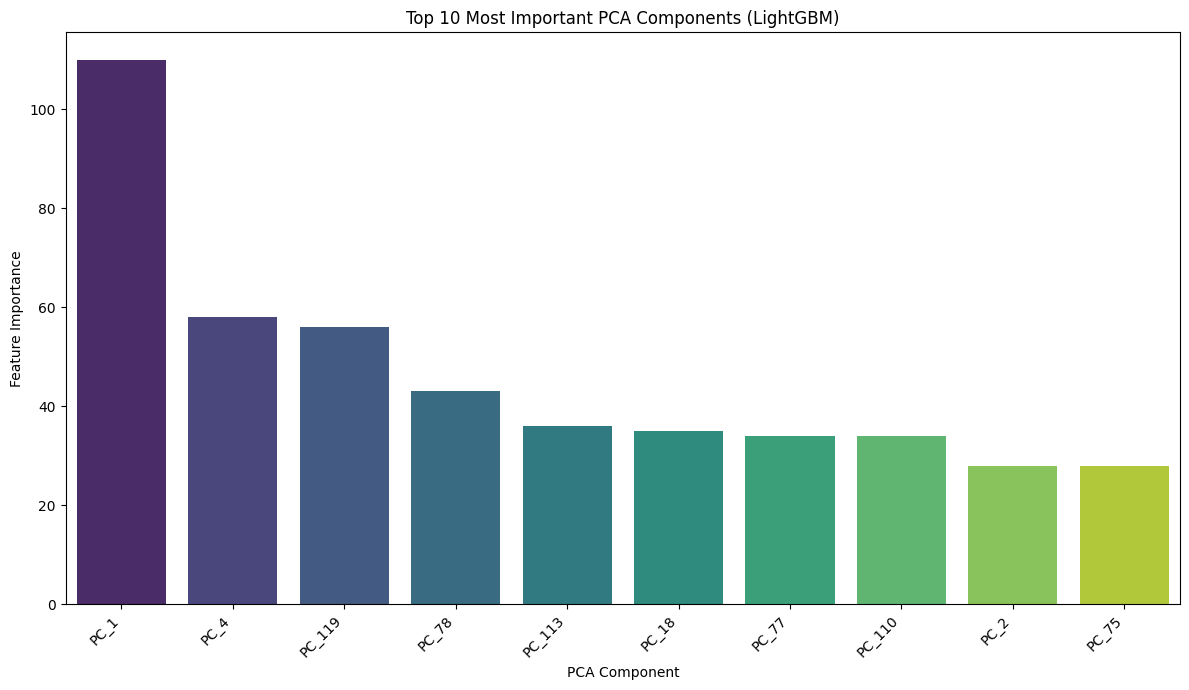

In [ ]:
print("\n--- Extracting Feature Importances ---")


feature_importances = best_lgbm_model.feature_importances_
feature_importances = pd.Series(feature_importances, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

print("\nTop 10 most important PCA components:")
display(feature_importances.head(10))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.head(10).index, y=feature_importances.head(10).values, hue=feature_importances.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Most Important PCA Components (LightGBM)')
plt.xlabel('PCA Component')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Unsupervised Learning / Trajectory Analysis

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported for clustering.")

Libraries imported for clustering.


###K-Means

Performing KMeans for k from 2 to 10...
  k=2: Inertia=172709.23, Silhouette Score=0.85
  k=3: Inertia=158935.85, Silhouette Score=0.51
  k=4: Inertia=141832.21, Silhouette Score=0.49
  k=5: Inertia=132063.94, Silhouette Score=0.48
  k=6: Inertia=126755.24, Silhouette Score=0.47
  k=7: Inertia=118938.99, Silhouette Score=0.14
  k=8: Inertia=113750.40, Silhouette Score=0.12
  k=9: Inertia=109761.73, Silhouette Score=0.13
  k=10: Inertia=103690.69, Silhouette Score=0.13


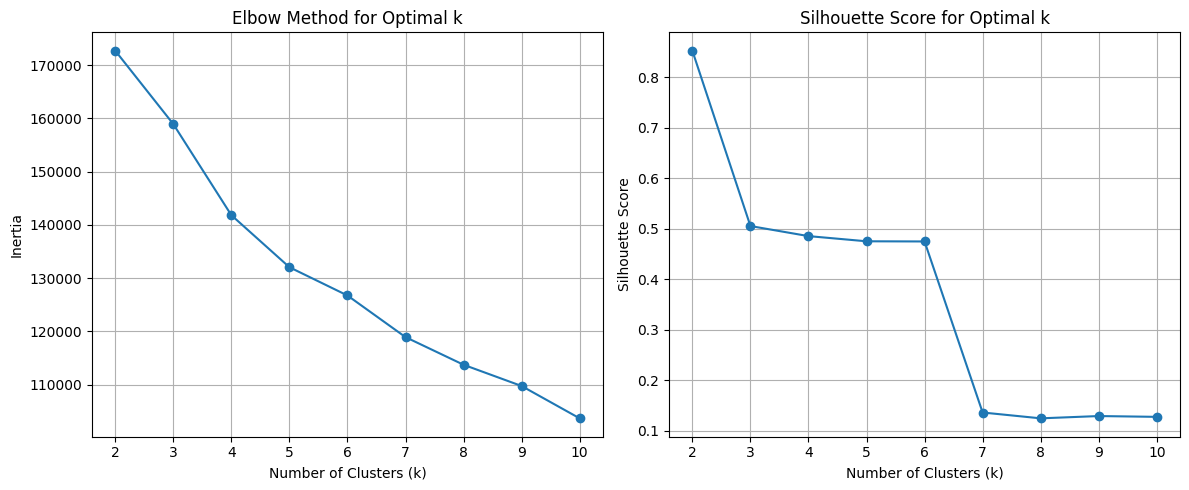

Inertia and Silhouette plots generated.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X_traj = trajectory_features_df.drop('patientunitstayid', axis=1)

# Imputations
imputer = SimpleImputer(strategy='median')
X_traj_imputed = imputer.fit_transform(X_traj)

# Scaling
scaler_traj = StandardScaler()
X_traj_scaled = scaler_traj.fit_transform(X_traj_imputed)

X_traj_scaled_df = pd.DataFrame(X_traj_scaled, columns=X_traj.columns)


inertia = []
silhouette_scores = []

max_clusters = 10
k_range = range(2, max_clusters + 1)

print(f"Performing KMeans for k from 2 to {max_clusters}...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_traj_scaled_df)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_traj_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"  k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={score:.2f}")

# Plotting the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)

# Plotting Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

print("Inertia and Silhouette plots generated.")

In [ ]:
from sklearn.cluster import KMeans
optimal_k = 2

print(f"Applying KMeans with optimal k = {optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_traj_scaled_df)

trajectory_features_df['cluster_label'] = cluster_labels

print("KMeans clustering applied and cluster labels added to trajectory_features_df.")
print("First 5 rows of trajectory_features_df with cluster labels:")
display(trajectory_features_df.head())
print("Distribution of cluster labels:")
display(trajectory_features_df['cluster_label'].value_counts())


Applying KMeans with optimal k = 2...
KMeans clustering applied and cluster labels added to trajectory_features_df.
First 5 rows of trajectory_features_df with cluster labels:


,patientunitstayid,heartrate_mean,heartrate_median,heartrate_std,heartrate_min,heartrate_max,temperature_mean,temperature_median,temperature_std,temperature_min,...,st3_median,st3_std,st3_min,st3_max,icp_mean,icp_median,icp_std,icp_min,icp_max,cluster_label
0,141764,106.652174,104.0,11.339450,90.0,138.0,37.1,37.1,0.0,37.1,...,-0.8,0.398147,-1.7,-0.5,11.0,11.0,0.0,11.0,11.0,0
1,141765,87.017817,86.0,9.587689,72.0,138.0,37.1,37.1,0.0,37.1,...,-0.7,0.065582,-0.9,-0.4,11.0,11.0,0.0,11.0,11.0,0
2,143870,45.449367,46.0,2.594820,40.0,55.0,37.1,37.1,0.0,37.1,...,0.1,0.051335,0.0,0.3,11.0,11.0,0.0,11.0,11.0,0
3,144815,83.800000,82.0,10.483560,68.0,118.0,37.1,37.1,0.0,37.1,...,0.0,0.096564,-0.9,0.0,11.0,11.0,0.0,11.0,11.0,0
4,145427,65.457983,64.0,7.862500,49.0,85.0,37.1,37.1,0.0,37.1,...,0.0,0.130738,-0.2,0.4,11.0,11.0,0.0,11.0,11.0,0


Distribution of cluster labels:


,count
cluster_label,
0,2367
1,8


####Characteristics of Clusters



In [ ]:
print("\nMean vital sign values per cluster:\n")
mean_vital_sign_cols = [col for col in trajectory_features_df.columns if col.endswith('_mean') and col.replace('_mean', '') in vital_sign_cols]

display(trajectory_features_df.groupby('cluster_label')[mean_vital_sign_cols].mean())


Mean vital sign values per cluster:



,heartrate_mean,temperature_mean,sao2_mean,respiration_mean,cvp_mean,etco2_mean,systemicsystolic_mean,systemicdiastolic_mean,systemicmean_mean,pasystolic_mean,padiastolic_mean,pamean_mean,st1_mean,st2_mean,st3_mean,icp_mean
cluster_label,,,,,,,,,,,,,,,,
0,83.777602,37.153021,95.956015,19.574267,16.105011,29.914918,122.730962,61.387216,80.651954,39.084543,18.191395,25.152090,0.244340,0.527810,0.386819,11.025665
1,79.266556,37.124805,96.917421,21.522138,11.722233,30.000000,123.208002,60.067974,79.320281,37.094021,17.017331,23.836005,114.935682,214.002393,275.694038,11.000000


### Hierarchical Clustering


--- Performing Hierarchical Clustering ---


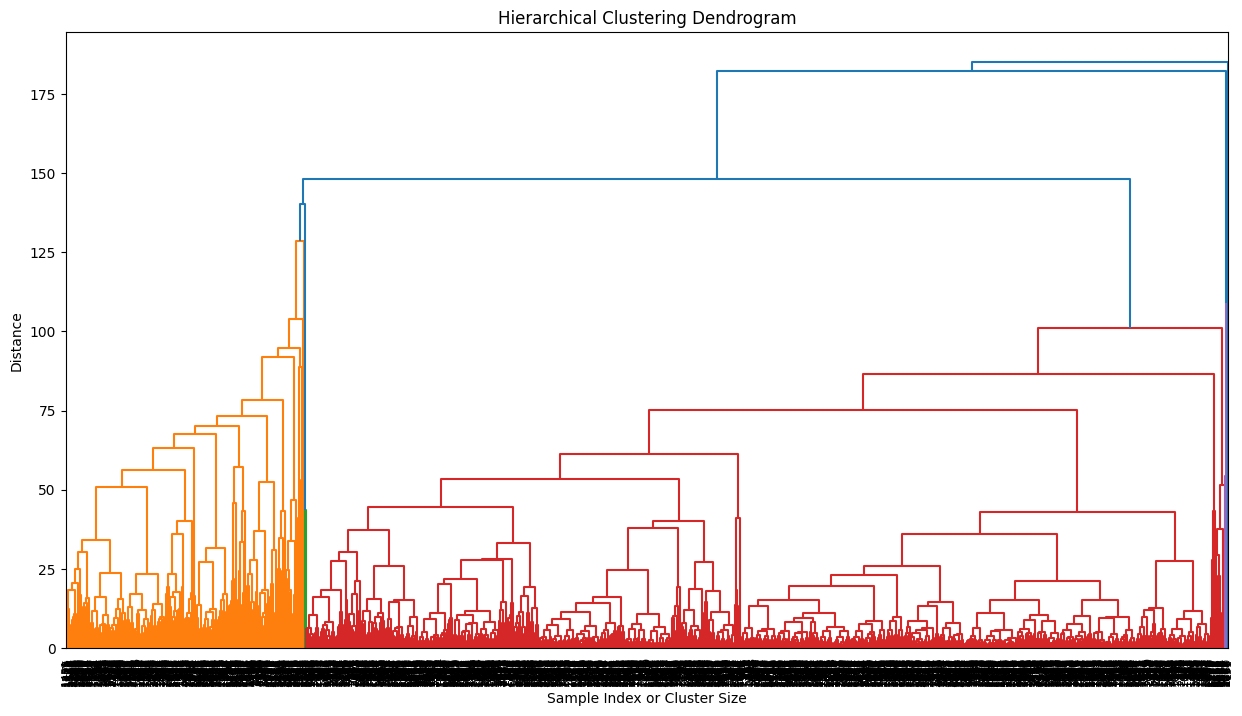

Dendrogram plotted. Analyze the dendrogram to determine a suitable number of clusters (e.g., by looking for large vertical drops).


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

print("\n--- Performing Hierarchical Clustering ---")

# hierarchical clustering
# Using ward method
linked = linkage(X_traj_scaled_df, method='ward')

# dendrogram
plt.figure(figsize=(15, 8))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False,
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

print("Dendrogram plotted. Analyze the dendrogram to determine a suitable number of clusters (e.g., by looking for large vertical drops).")

In [ ]:


hierarchical_clusters = fcluster(linked, t=3, criterion='maxclust')

# Adding the hierarchical cluster labels to the trajectory_features_df
trajectory_features_df['hierarchical_cluster_label'] = hierarchical_clusters

print(f"Hierarchical clustering applied with {trajectory_features_df['hierarchical_cluster_label'].nunique()} clusters.")
print("First 5 rows of trajectory_features_df with hierarchical cluster labels:")
display(trajectory_features_df.head())

print("Distribution of hierarchical cluster labels:")
display(trajectory_features_df['hierarchical_cluster_label'].value_counts())

Hierarchical clustering applied with 3 clusters.
First 5 rows of trajectory_features_df with hierarchical cluster labels:


,patientunitstayid,heartrate_mean,heartrate_median,heartrate_std,heartrate_min,heartrate_max,temperature_mean,temperature_median,temperature_std,temperature_min,...,st3_std,st3_min,st3_max,icp_mean,icp_median,icp_std,icp_min,icp_max,cluster_label,hierarchical_cluster_label
0,141764,106.652174,104.0,11.339450,90.0,138.0,37.1,37.1,0.0,37.1,...,0.398147,-1.7,-0.5,11.0,11.0,0.0,11.0,11.0,0,2
1,141765,87.017817,86.0,9.587689,72.0,138.0,37.1,37.1,0.0,37.1,...,0.065582,-0.9,-0.4,11.0,11.0,0.0,11.0,11.0,0,2
2,143870,45.449367,46.0,2.594820,40.0,55.0,37.1,37.1,0.0,37.1,...,0.051335,0.0,0.3,11.0,11.0,0.0,11.0,11.0,0,2
3,144815,83.800000,82.0,10.483560,68.0,118.0,37.1,37.1,0.0,37.1,...,0.096564,-0.9,0.0,11.0,11.0,0.0,11.0,11.0,0,2
4,145427,65.457983,64.0,7.862500,49.0,85.0,37.1,37.1,0.0,37.1,...,0.130738,-0.2,0.4,11.0,11.0,0.0,11.0,11.0,0,2


Distribution of hierarchical cluster labels:


,count
hierarchical_cluster_label,
2,2369
1,5
3,1


#### Characteristics of Hierarchical Clusters



In [ ]:
print("\nMean vital sign values per hierarchical cluster:\n")

mean_vital_sign_cols = [col for col in trajectory_features_df.columns if col.endswith('_mean') and col.replace('_mean', '') in vital_sign_cols]

display(trajectory_features_df.groupby('hierarchical_cluster_label')[mean_vital_sign_cols].mean())

# Merging hierarchical cluster labels with the main patient data
clustered_patients_df_hierarchical = pd.merge(merged_df_with_vitals, trajectory_features_df[['patientunitstayid', 'hierarchical_cluster_label']], on='patientunitstayid', how='left')

clustered_patients_df_hierarchical['hierarchical_cluster_label'] = clustered_patients_df_hierarchical['hierarchical_cluster_label'].fillna(-1).astype(int)

print("\nMean hospital mortality and ventilation days per hierarchical cluster (merged data):\n")
hierarchical_cluster_summary = clustered_patients_df_hierarchical.groupby('hierarchical_cluster_label')[['actualhospitalmortality', 'actualventdays']].mean()
display(hierarchical_cluster_summary)

print("\nGender distribution per hierarchical cluster (merged data):\n")
display(clustered_patients_df_hierarchical.groupby('hierarchical_cluster_label')['gender'].value_counts(normalize=True).unstack())

print("\nMean age per hierarchical cluster (merged data):\n")
display(clustered_patients_df_hierarchical.groupby('hierarchical_cluster_label')['age'].mean())


Mean vital sign values per hierarchical cluster:



,heartrate_mean,temperature_mean,sao2_mean,respiration_mean,cvp_mean,etco2_mean,systemicsystolic_mean,systemicdiastolic_mean,systemicmean_mean,pasystolic_mean,padiastolic_mean,pamean_mean,st1_mean,st2_mean,st3_mean,icp_mean
hierarchical_cluster_label,,,,,,,,,,,,,,,,
1,80.089601,37.100000,96.337454,24.058163,12.545521,30.00000,122.143201,58.686575,78.079174,39.000000,18.000000,25.000000,125.699640,277.688716,356.238546,11.000000
2,83.775132,37.153195,95.958182,19.567526,16.100330,29.91499,122.728095,61.383654,80.646978,38.976967,18.078164,25.041235,0.366824,0.663796,0.565615,11.025644
3,71.982184,36.779540,96.606322,28.706897,9.929885,30.00000,136.277011,72.775862,94.650575,278.432759,278.000000,278.000000,0.334626,0.370718,0.017701,11.000000



Mean hospital mortality and ventilation days per hierarchical cluster (merged data):



,actualhospitalmortality,actualventdays
hierarchical_cluster_label,,
-1,0.064516,0.258065
1,0.200000,2.000000
2,0.084398,0.969461
3,0.000000,0.000000



Gender distribution per hierarchical cluster (merged data):



gender,Female,Male
hierarchical_cluster_label,,
-1,0.397727,0.602273
1,NaN,1.000000
2,0.395204,0.604796
3,NaN,1.000000



Mean age per hierarchical cluster (merged data):



,age
hierarchical_cluster_label,
-1,59.937500
1,77.000000
2,63.268825
3,73.000000


In [ ]:
# @title
print("--- Merging trajectory_features_df with merged_df_with_vitals ---")

# Merging trajectory_features_df with merged_df_with_vitals
clustered_patients_df = pd.merge(merged_df_with_vitals, trajectory_features_df[['patientunitstayid', 'cluster_label']], on='patientunitstayid', how='left')

print("First 5 rows of clustered_patients_df:")
display(clustered_patients_df.head())

print("\nColumn information (types, non-null counts) of clustered_patients_df:")
clustered_patients_df.info()

print("\nMissing values in clustered_patients_df after merge (should be none for cluster_label if merge is successful):")
display(clustered_patients_df.isnull().sum()[clustered_patients_df.isnull().sum() > 0].sort_values(ascending=False))

print("\n--- Analyzing Cluster Characteristics ---")

clustered_patients_df['cluster_label'] = clustered_patients_df['cluster_label'].fillna(-1)

# cluster_label to integer type
clustered_patients_df['cluster_label'] = clustered_patients_df['cluster_label'].astype(int)

#  mean hospital mortality and ventilation days for each cluster
print("\nMean hospital mortality and ventilation days per cluster:")
cluster_summary = clustered_patients_df.groupby('cluster_label')[['actualhospitalmortality', 'actualventdays']].mean()
display(cluster_summary)

print("\nGender distribution per cluster:")
display(clustered_patients_df.groupby('cluster_label')['gender'].value_counts(normalize=True).unstack())

print("\nMean age per cluster:")
display(clustered_patients_df.groupby('cluster_label')['age'].mean())

print("\nKey mean vital signs per cluster (from merged_df_with_vitals features):")
key_vital_means = ['heartrate_mean', 'temperature_mean', 'sao2_mean', 'respiration_mean', 'systemicmean_mean']
key_vital_summary = clustered_patients_df.groupby('cluster_label')[key_vital_means].mean()
display(key_vital_summary)



--- Merging trajectory_features_df with merged_df_with_vitals ---
First 5 rows of clustered_patients_df:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,st3_std,icp_mean,icp_min,icp_max,icp_std,num_unique_diagnoses,num_major_diagnoses,num_unique_treatments,num_treatments_24h,cluster_label
0,141764,129391,Female,87.0,Caucasian,59,91,"Sepsis, pulmonary",157.5,23:36:00,...,0.398147,11.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
1,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,0.063093,11.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
2,141765,129391,Female,87.0,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,0.063093,11.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
3,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.051335,11.0,11.0,11.0,0.0,3.0,0.0,0.0,0.0,0.0
4,143870,131022,Male,76.0,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,0.051335,11.0,11.0,11.0,0.0,3.0,0.0,0.0,0.0,0.0



Column information (types, non-null counts) of clustered_patients_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Columns: 529 entries, patientunitstayid to cluster_label
dtypes: float64(501), int64(9), object(19)
memory usage: 17.6+ MB

Missing values in clustered_patients_df after merge (should be none for cluster_label if merge is successful):


,0
apachepatientresultsid,682
physicianspeciality,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachescore,682
apacheversion,682
predictedicumortality,682
actualicumortality,682
predictediculos,682
actualiculos,682



--- Analyzing Cluster Characteristics ---

Mean hospital mortality and ventilation days per cluster:


...

gender,Female,Male
cluster_label,,
-1,0.397727,0.602273
0,0.395583,0.604417
1,NaN,1.000000



Mean age per cluster:


,age
cluster_label,
-1,59.937500
0,63.261402
1,75.000000



Key mean vital signs per cluster (from merged_df_with_vitals features):


,heartrate_mean,temperature_mean,sao2_mean,respiration_mean,systemicmean_mean
cluster_label,,,,,
-1,82.823129,37.100000,96.724739,19.000000,80.000000
0,84.328471,37.182525,96.178703,19.462741,80.294544
1,79.987390,37.124608,97.148496,19.822019,77.242182


In [ ]:
# @title
